In [1]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(42)


from lymph.models import Unilateral
from lymixture import LymphMixture
from lymixture.utils import binom_pmf, late_binomial, normalize

dataset = pd.read_csv('../../data/mixture_model_data_combined.csv', header = [0,1,2],)
dataset_staging = dataset.copy()
dataset_staging['tumor','1','t_stage'] = dataset_staging['tumor','1','t_stage'].replace([0,1,2], 'early')
dataset_staging['tumor','1','t_stage'] = dataset_staging['tumor','1','t_stage'].replace([3,4], 'late')
dataset_staging = dataset_staging[~(dataset_staging['tumor']['1']['subsite'].str.startswith(('C00.4')))]

In [2]:
dataset_staging_main_groups = dataset_staging.copy()

# Reduce to only main subsite
dataset_staging_main_groups.loc[:, ('tumor', '1', 'subsite')] = (
    dataset_staging_main_groups.loc[:, ('tumor', '1', 'subsite')].str.replace(r'\..*', '', regex=True)
)

dataset_staging_main_groups['tumor']['1']['subsite'].value_counts()


subsite
C09    452
C12    227
C01    212
C10    169
C13    165
C02    158
C04     99
C05     61
C06     46
C03     45
Name: count, dtype: int64

In [3]:
graph = {
    ("tumor", "T"): ["I", "II", "III", "IV", "V"],
    ("lnl", "I"): ["II"],
    ("lnl", "II"): ["III"],
    ("lnl", "III"): ["IV"],
    ("lnl", "IV"): ["V"],
    ("lnl", "V"): [],

}

num_components = 3

mixture = LymphMixture(
    model_cls=Unilateral,
    model_kwargs={"graph_dict": graph},
    num_components=num_components,
    universal_p= False
)
mixture.load_patient_data(
    dataset_staging_main_groups,
    split_by=("tumor", "1", "subsite"),
    mapping=lambda x: x,
)

mixture.set_distribution("early", binom_pmf(np.arange(11), 10, 0.3))
mixture.set_distribution("late", late_binomial)
mixture.set_modality("diagnostic_consensus", 1., 1.)

Initialize random model parameters and latent variables/responsibilities.

In [4]:
from lymixture.em import expectation, maximization

params = {k: rng.uniform() for k in mixture.get_params()}

mixture.set_params(**params)
mixture.normalize_mixture_coefs()
latent = normalize(rng.uniform(size=mixture.get_resps().shape).T, axis=0).T

In [5]:
def to_numpy(params: dict[str, float]) -> np.ndarray:
    return np.array([p for p in params.values()])

In [7]:
mixture.get_mixture_coefs()

,C01,C02,C03,C04,C05,C06,C09,C10,C12,C13
0,0.281875,0.487351,0.366537,0.442804,0.274028,0.189771,0.485022,0.057583,0.692963,0.446088
1,0.566157,0.508777,0.185485,0.199379,0.290183,0.158230,0.113625,0.429235,0.189988,0.473030
2,0.151967,0.003872,0.447978,0.357818,0.435789,0.651999,0.401353,0.513182,0.117050,0.080882


Iterate the computation of the expectation value of the latent variables (E-step) and the maximization of the (complete) data log-likelihood w.r.t. the model parameters (M-step).

In [141]:
def check_convergence(params_history, likelihood_history, steps_back_list):
    current_params = params_history[-1]
    current_likelihood = likelihood_history[-1]
    for steps_back in steps_back_list:
        previous_params = params_history[-steps_back - 1]
        if np.allclose(to_numpy(current_params), to_numpy(previous_params)):
            print('stopped due to parameter similarity')
            return True  # Return True if any of the steps is close
        elif (np.isclose(current_likelihood, likelihood_history[-steps_back - 1],rtol = 0, atol = 0.001)) and np.all(current_likelihood >= np.array(likelihood_history)):
            print('stopped due to likelihood similarity')
            return True
    return False

In [120]:
is_converged = False
count = 0
params_history = []
likelihood_history = []
params_history.append(params.copy())
likelihood_history.append(mixture.likelihood(use_complete=False))
# Number of steps to look back for convergence
look_back_steps = 3

while not is_converged:
    print(count)
    print(likelihood_history[-1])
    old_params = params
    latent = expectation(mixture, params)
    params = maximization(mixture, latent)
    
    # Append current params and likelihood to history
    params_history.append(params.copy())
    likelihood_history.append(mixture.likelihood(use_complete=False))
    
    # Check if converged
    if count >= 3:  # Ensure enough history is available
        is_converged = check_convergence(params_history, likelihood_history,list(range(1,look_back_steps+1)))
    count += 1

0
-3556.8356225485845


KeyboardInterrupt: 

In [91]:
len(mixture.get_params())

60

In [15]:
mixture.components[0].load_patient_data(dataset)


/home/yoel/Documents/Mixture_model/.venv/lib/python3.10/site-packages/lymph/models/unilateral.py:531: DataWarning: Modality enbloc_positive does not contain involvement data for LNL I. Assuming unknown.
  warnings.warn(
/home/yoel/Documents/Mixture_model/.venv/lib/python3.10/site-packages/lymph/models/unilateral.py:531: DataWarning: Modality enbloc_positive does not contain involvement data for LNL II. Assuming unknown.
  warnings.warn(
/home/yoel/Documents/Mixture_model/.venv/lib/python3.10/site-packages/lymph/models/unilateral.py:531: DataWarning: Modality enbloc_positive does not contain involvement data for LNL V. Assuming unknown.
  warnings.warn(
/home/yoel/Documents/Mixture_model/.venv/lib/python3.10/site-packages/lymph/models/unilateral.py:531: DataWarning: Modality enbloc_dissected does not contain involvement data for LNL I. Assuming unknown.
  warnings.warn(
/home/yoel/Documents/Mixture_model/.venv/lib/python3.10/site-packages/lymph/models/unilateral.py:531: DataWarning: Mod

In [155]:
mixture.likelihood(use_complete = False)

-10675.80989864238

In [107]:
likelihood_history

[-8861.149052667717,
 -3457.443680231825,
 -3429.300770722326,
 -3407.9617660499785,
 -3378.641010454833,
 -3336.734531417028,
 -3297.4312294650545,
 -3273.848159632145,
 -3261.832001797866,
 -3255.8830846501305,
 -3252.147239400156,
 -3249.1842524015105,
 -3246.591464706784,
 -3244.249503116841,
 -3242.0992888761652,
 -3240.1780368271707,
 -3238.415688016317,
 -3236.8017858449703,
 -3235.317264193238,
 -3233.937328989603,
 -3232.6497119883215,
 -3231.439432377087,
 -3230.298153448658,
 -3229.2246576573452,
 -3228.211954390273,
 -3227.2585199525065,
 -3226.3651994288684,
 -3225.5267715365535,
 -3224.7434015456724,
 -3224.0109591708147,
 -3223.326577144933,
 -3222.6892374498043,
 -3222.0954696814733,
 -3221.5426498846255,
 -3221.0080211763916,
 -3220.492038025968,
 -3220.0157560471393,
 -3219.5574432768003,
 -3219.1144733640012,
 -3218.6994881244063,
 -3218.2947353335903,
 -3217.914010291013,
 -3217.554403333669,
 -3217.2113479765403,
 -3216.8939494235933,
 -3216.598816673443,
 -3216.32

In [16]:
# a = np.array(likelihood_history)
# np.savetxt('likelihoods_3_comp_t_stage_new.txt', a, fmt='%.6f')
b = np.loadtxt('likelihoods_3_comp_t_stage_new.txt', dtype=float)
b


FileNotFoundError: likelihoods_3_comp_t_stage_new.txt not found.

In [109]:
differences = []
for i in range(len(params_history)-1):
    differences.append(np.abs(np.array(list(params_history[i].values())) - np.array(list(params_history[i+1].values()))).sum())
differences

[24.43162161614799,
 1.666686978531569,
 1.336110362721769,
 1.4675629832925035,
 1.9186646529454765,
 2.376928232266133,
 1.9769210123675185,
 1.3496425371618281,
 0.820322903369987,
 0.5022227074264299,
 0.36696754489295763,
 0.31254553881244734,
 0.2895998496520673,
 0.27464144579790206,
 0.25105130214856897,
 0.2416624226215413,
 0.23451393029671153,
 0.22727006829188073,
 0.2256281382637627,
 0.2238237683591441,
 0.21946019453077772,
 0.21295282259414502,
 0.20547726932606614,
 0.19680468891844533,
 0.18875019972990414,
 0.18000755681860126,
 0.1700675108104997,
 0.16124987984647624,
 0.1515596676359723,
 0.14355908200541145,
 0.13558190891194757,
 0.1274232283353071,
 0.12007004658097062,
 0.11391812703824492,
 0.11225669265011129,
 0.11408407893621952,
 0.11424173218345594,
 0.11547733494490703,
 0.11695488642605958,
 0.11713121933812609,
 0.11796372309036388,
 0.11726436060462908,
 0.11527172687371082,
 0.11310415656174175,
 0.10972034563004372,
 0.10545745363185703,
 0.1002613

Text(0.5, 1.0, 'Convergence of EM algorithm 3 comp 3 locs')

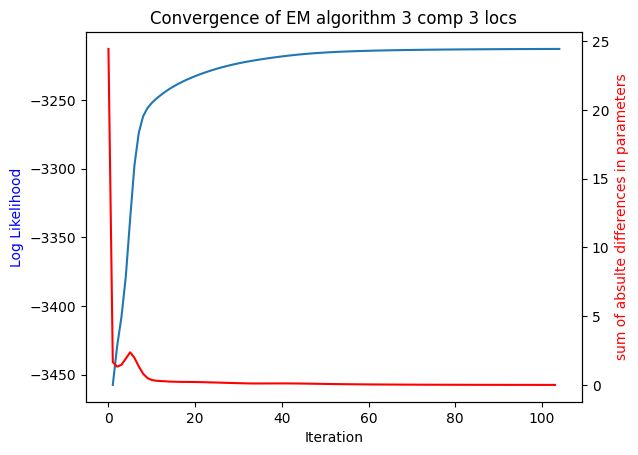

In [110]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots()
ax1.plot(np.array(range(len(likelihood_history[1:])))+1,likelihood_history[1:])
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Log Likelihood', color='blue')
ax2 = ax1.twinx()
ax2.plot(differences, color='red')  
ax2.set_ylabel('sum of absulte differences in parameters', color='red')
ax1.set_title('Convergence of EM algorithm 3 comp 3 locs')

In [113]:
params = params_history[np.argmax(likelihood_history)]
mixture.set_params(**params)
mixture.normalize_mixture_coefs()
latent = normalize(rng.uniform(size=mixture.get_resps().shape).T, axis=0).T

In [80]:
mixture.likelihood(use_complete=False)

-3215.020041797161

In [81]:
mixture._mixture_coefs

,C01,C02,C03,C04,C05,C06,C09,C10,C12,C13
0,0.112546,0.671064,1.000000e+00,0.884262,0.620156,0.943423,0.179112,0.282512,7.356314e-29,8.209371e-03
1,0.149331,0.146344,5.673459e-44,0.058957,0.019667,0.000002,0.245432,0.388564,9.802305e-01,9.917899e-01
2,0.738122,0.182592,1.067300e-33,0.056781,0.360177,0.056574,0.575456,0.328924,1.976947e-02,7.129680e-07


In [78]:
mixture.set_params(**{'0_TtoI_spread': 0.04823361384993334, # These are the parameters from the model with VI and VII added
 '0_TtoII_spread': 0.026920135841119016,
 '0_TtoIII_spread': 0.014254995332923537,
 '0_TtoIV_spread': 0.003849865583672014,
 '0_TtoV_spread': 6.610696135189607e-05,
 '0_TtoVI_spread': 0.15195070816120804,
 '0_TtoVII_spread': 0.008200534552579247,
 '0_ItoII_spread': 0.18381160248446954,
 '0_IItoIII_spread': 0.04512085989398958,
 '0_IIItoIV_spread': 0.0005545711246433523,
 '0_IVtoV_spread': 6.610696135189607e-05,
 '0_late_p': 0.6861108545891871,
 '0_C01_coef': 0.11254643298811029,
 '0_C02_coef': 0.6710638701223067,
 '0_C03_coef': 1.0,
 '0_C04_coef': 0.8842620370463824,
 '0_C05_coef': 0.6201559993825714,
 '0_C06_coef': 0.9434234864064953,
 '0_C09_coef': 0.179111574780004,
 '0_C10_coef': 0.2825119601626327,
 '0_C12_coef': 7.356313604506492e-29,
 '0_C13_coef': 0.008209371437202843,
 '1_TtoI_spread': 0.0114368535834213,
 '1_TtoII_spread': 0.2741694830320249,
 '1_TtoIII_spread': 0.13539127709370613,
 '1_TtoIV_spread': 0.04077770742386316,
 '1_TtoV_spread': 0.032963814800182144,
 '1_TtoVI_spread': 0.011044341210374346,
 '1_TtoVII_spread': 0.020983054739507095,
 '1_ItoII_spread': 0.7634240033034118,
 '1_IItoIII_spread': 0.2626415649335421,
 '1_IIItoIV_spread': 0.08604719582963476,
 '1_IVtoV_spread': 0.09003940677590355,
 '1_late_p': 0.38257476294883425,
 '1_C01_coef': 0.14933109232540992,
 '1_C02_coef': 0.14634379477499532,
 '1_C03_coef': 5.673459448824119e-44,
 '1_C04_coef': 0.05895713616835305,
 '1_C05_coef': 0.01966657078907267,
 '1_C06_coef': 2.3710371727175635e-06,
 '1_C09_coef': 0.24543197173414322,
 '1_C10_coef': 0.3885641490861775,
 '1_C12_coef': 0.9802305274401071,
 '1_C13_coef': 0.9917899155947861,
 '2_TtoI_spread': 0.03573483146420709,
 '2_TtoII_spread': 0.9996249180777914,
 '2_TtoIII_spread': 6.610696135189607e-05,
 '2_TtoIV_spread': 0.007070541605792514,
 '2_TtoV_spread': 0.01692738000558276,
 '2_TtoVI_spread': 0.25808409321642894,
 '2_TtoVII_spread': 0.03021305660856036,
 '2_ItoII_spread': 0.9999338930386481,
 '2_IItoIII_spread': 0.15086434980692978,
 '2_IIItoIV_spread': 0.19975353670518547,
 '2_IVtoV_spread': 0.1586628877538901,
 '2_late_p': 0.4588218591178673,
 '2_C01_coef': 0.7381224746864797,
 '2_C02_coef': 0.18259233510269793,
 '2_C03_coef': 1.0672998466589147e-33,
 '2_C04_coef': 0.056780826785264596,
 '2_C05_coef': 0.36017742982835593,
 '2_C06_coef': 0.056574142556331995,
 '2_C09_coef': 0.5754564534858528,
 '2_C10_coef': 0.32892389075118983,
 '2_C12_coef': 0.019769472559893028,
 '2_C13_coef': 7.129680110653186e-07})


()

In [85]:
subgroup = 'C13'
t_stage = 'late'
desired_lnl = 'II'
lnls = np.array(['I','II','III','IV','V'])
involvement = {'I': None, 'II': None, 'III': None, 'IV': None, 'V': None}



subgroup_combinations_short = pd.DataFrame(mixture.subgroups[subgroup].patient_data['_model']['diagnostic_consensus'].loc[mixture.subgroups[subgroup].patient_data['_model']['#']['t_stage'] == t_stage].value_counts()/((mixture.subgroups[subgroup].patient_data['_model']['#']['t_stage'] == t_stage) & (np.all(mixture.subgroups[subgroup].patient_data['_model']['diagnostic_consensus'].notna(),axis = 1))).sum().sum())
# Convert the Series to DataFrame
df = subgroup_combinations_short.reset_index()
df.columns = ['I', 'II', 'III', 'IV', 'V', 'prevalence']

# Convert boolean columns to tuples
df['predicted'] = df[['I', 'II', 'III', 'IV', 'V']].apply(lambda row: tuple(int(x) for x in row), axis=1)

# Drop the original boolean columns
df = df.drop(columns=['I', 'II', 'III', 'IV', 'V'])

import itertools

# Define the number of features (length of the combination list)
num_features = 5  # Update based on your data length

# Generate all possible combinations of binary values (0 or 1)
combinations = list(itertools.product([0, 1], repeat=num_features))

# Create a DataFrame with all combinations and default probability of 0
subgroup_combinations = pd.DataFrame(combinations, columns=[f'Feature_{i+1}' for i in range(num_features)])
subgroup_combinations['predicted'] = subgroup_combinations.apply(lambda row: tuple(row), axis=1)
subgroup_combinations.drop(columns=[f'Feature_{i+1}' for i in range(num_features)], inplace=True)
# Merge with the existing probabilities
subgroup_combinations = pd.merge(subgroup_combinations, df, on='predicted', how='left').fillna(0)
subgroup_combinations.drop(columns=['predicted'], inplace=True)

mixture.state_dist(subgroup=subgroup)
df = pd.DataFrame(np.array([mixture.state_dist(subgroup=subgroup,t_stage=t_stage)]), columns = [str(col) for col in mixture.components[0].graph.state_list])
df = df.T
df.columns = ['predicted']
subgroup_combinations['index'] = df.index
subgroup_combinations.set_index('index', inplace=True)
df_final = pd.concat([subgroup_combinations, df],axis = 1)
df_final['difference'] = df_final['predicted'] - df_final['prevalence']

lnl_index = np.where(lnls == desired_lnl)[0][0]
indices = []
for i, state in enumerate(mixture.components[0].graph.state_list):
    if state[lnl_index] == 1:
        indices.append(i)
print(desired_lnl, subgroup_combinations.iloc[indices].sum()*100,)
involvement[desired_lnl] = True
print('predicted involvement of', desired_lnl, mixture.risk(subgroup=subgroup, t_stage=t_stage, involvement=involvement)*100)

(df_final*100)

II prevalence    70.175439
dtype: float64
predicted involvement of II 67.83300808923859


,prevalence,predicted,difference
[0 0 0 0 0],16.666667,16.853478,0.186811
[0 0 0 0 1],0.877193,1.328806,0.451613
[0 0 0 1 0],0.877193,1.945468,1.068275
[0 0 0 1 1],0.000000,0.472739,0.472739
[0 0 1 0 0],7.894737,7.537896,-0.356841
[0 0 1 0 1],0.877193,0.792080,-0.085113
[0 0 1 1 0],2.631579,2.097701,-0.533878
[0 0 1 1 1],0.000000,0.589989,0.589989
[0 1 0 0 0],21.052632,16.557828,-4.494803
[0 1 0 0 1],1.754386,1.703924,-0.050462


In [77]:
mixture.risk(subgroup = 'C05', t_stage = 'early', involvement = {'I': None, 'II': True, 'III': None, 'IV': None, 'V': None})

0.41098068113476044

## Load/Save Data

In [6]:
import pickle 
from lymixture.em import expectation, maximization

# with open('params_I_to_V_ipsi_3_comp_split_t_stages_start2.pkl', 'wb') as f:
#     pickle.dump(params, f)
        
with open('params_I_to_V_ipsi_3_comp_split_t_stages_new.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
params = loaded_dict
mixture.set_params(**loaded_dict)
mixture.normalize_mixture_coefs()
mixture.set_resps(expectation(mixture, loaded_dict))
mixture.likelihood(use_complete= False)

-3212.64499150515

In [144]:
mixture.patient_data['_model']['diagnostic_consensus']

,I,II,III,IV,V
0,False,True,False,False,False
1,False,True,True,False,False
2,False,True,False,False,False
3,False,True,True,True,True
4,False,True,False,False,False
...,...,...,...,...,...
1629,False,True,True,False,False
1630,False,False,False,False,False
1631,False,True,False,False,False
1632,False,False,False,False,True


## Mixture evaluation

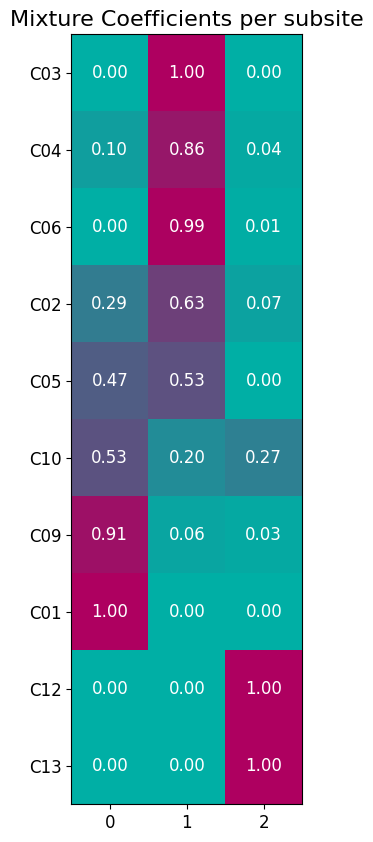

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# USZ colors
usz_blue = '#005ea8'
usz_green = '#00afa5'
usz_red = '#ae0060'
usz_orange = '#f17900'
usz_gray = '#c5d5db'

# colormaps
white_to_blue  = LinearSegmentedColormap.from_list("white_to_blue", 
                                                   ["#ffffff", usz_blue], 
                                                   N=256)
white_to_green = LinearSegmentedColormap.from_list("white_to_green", 
                                                   ["#ffffff", usz_green], 
                                                   N=256)
green_to_red   = LinearSegmentedColormap.from_list("green_to_red", 
                                                   [usz_green, usz_red], 
                                                   N=256)

h = usz_gray.lstrip('#')
gray_rgba = tuple(int(h[i:i+2], 16) / 255. for i in (0, 2, 4)) + (1.0,)
tmp = LinearSegmentedColormap.from_list("tmp", [usz_green, usz_red], N=128)

matrix = mixture.get_mixture_coefs()[['C03', 'C04', 'C06', 'C02', 'C05', 'C10', 'C09', 'C01', 'C12', 'C13']]

# Transpose the matrix to rotate by 90°
matrix_rotated = matrix.T

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 10))

# Display the rotated matrix using imshow
cax = ax.imshow(matrix_rotated.values, cmap=tmp, origin='upper')

# Loop over the data and create text annotations
for i in range(matrix_rotated.shape[0]):  # Rows (previously columns)
    for j in range(matrix_rotated.shape[1]):  # Columns (previously rows)
        value = matrix_rotated.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", 
                color="white", fontsize=12)


# Optional: Set axis labels and title
ax.set_xticks(range(matrix_rotated.shape[1]))
ax.set_xticklabels(matrix.index, fontsize = 12)  # Original row labels
ax.set_yticks(range(matrix_rotated.shape[0]))
ax.set_yticklabels(matrix.columns, fontsize = 12)  # Original column labels
ax.set_title("Mixture Coefficients per subsite", fontsize = 16)
plt.show()


2d Simplex plot

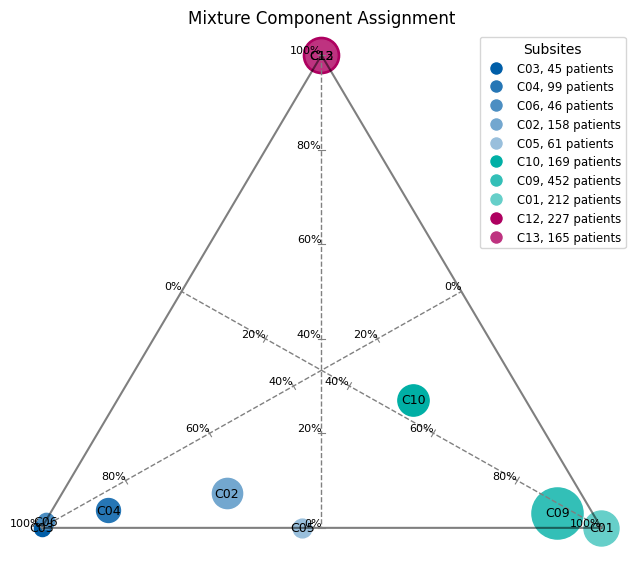

In [9]:
from matplotlib.lines import Line2D
# colormaps
blue_to_white = LinearSegmentedColormap.from_list("blue to white", 
                                                   [usz_blue, "#ffffff"], 
                                                   N=256)
green_to_white = LinearSegmentedColormap.from_list("green_to_white", 
                                                   [usz_green, "#ffffff"], 
                                                   N=256)
red_to_white   = LinearSegmentedColormap.from_list("red_to_white", 
                                                   [usz_red, "#ffffff"], 
                                                   N=256)
orange_to_white   = LinearSegmentedColormap.from_list("orange_to_white", 
                                                   [usz_orange, "#ffffff"], 
                                                   N=256)
colors_ordered= [blue_to_white(0), blue_to_white(0.15), blue_to_white(0.3), blue_to_white(0.45), blue_to_white(0.6), green_to_white(0), green_to_white(0.2), green_to_white(0.4), red_to_white(0), red_to_white(0.2)]  

# Define the plane's normal vector
normal_vector = np.array([1,1,1])/np.sqrt(3)

v1 = np.array([1,-1,0])/np.sqrt(2)

# Calculate the second orthogonal vector using the cross product
v2 = np.cross(normal_vector, v1) *-1

# Project the point onto the new coordinate system
origin = np.array([0, 1, 0])
x_origin =  origin @ v1
y_origin = origin @ v2

x_vals = matrix.T @ v1 - x_origin
y_vals = matrix.T @ v2 - y_origin

extremes = np.array([[1,0,0],
                    [0,1,0],
                    [0,0,1]])
extremes_x = extremes @ v1 - x_origin
extremes_y = extremes @ v2 - y_origin

# Plot the point in 2D
import matplotlib.pyplot as plt
odered_value_counts = dataset_staging_main_groups['tumor']['1']['subsite'].value_counts()[['C03', 'C04', 'C06', 'C02', 'C05', 'C10', 'C09', 'C01', 'C12', 'C13']]
sizes = odered_value_counts * 3

# Define the subsite labels
subsites = ['C03', 'C04', 'C06', 'C02', 'C05', 'C10', 'C09', 'C01', 'C12', 'C13']
plt.figure(figsize=(8, 6.8))
# Plot the points with varying sizes and colors
for i in range(len(x_vals)):
    plt.scatter(x_vals[i], y_vals[i], s=sizes[i], color=colors_ordered[i], label=subsites[i])
    plt.text(x_vals[i], y_vals[i], subsites[i], fontsize=9, ha='center', va='center')

legend_text = []
for index in range(len(subsites)):
    legend_text.append(subsites[index] + ', ' + str(odered_value_counts[index]) + ' patients')

legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=subsite)
                   for color, subsite in zip(colors_ordered, legend_text)]

# Add a legend with fixed dot sizes
plt.legend(handles=legend_elements, loc='upper right', title='Subsites', fontsize='small')
# plt.scatter(x_vals, y_vals, s=sizes, c = colors_ordered)
# Connect the points
plt.plot(extremes_x, extremes_y, color='black', alpha = 0.5)
# close the triangle by connecting the last point to the first
plt.plot([extremes_x[-1], extremes_x[0]], [extremes_y[-1], extremes_y[0]], color='black', alpha = 0.5)

# Calculate midpoints of each side of the triangle
midpoints_x = (extremes_x[0] + extremes_x[1]) / 2, (extremes_x[1] + extremes_x[2]) / 2, (extremes_x[2] + extremes_x[0]) / 2
midpoints_y = (extremes_y[0] + extremes_y[1]) / 2, (extremes_y[1] + extremes_y[2]) / 2, (extremes_y[2] + extremes_y[0]) / 2

# Draw lines from each vertex to the midpoint of the opposite side
plt.plot([extremes_x[0], midpoints_x[1]], [extremes_y[0], midpoints_y[1]], color='gray', linestyle='--', linewidth=1)
plt.plot([extremes_x[1], midpoints_x[2]], [extremes_y[1], midpoints_y[2]], color='gray', linestyle='--', linewidth=1)
plt.plot([extremes_x[2], midpoints_x[0]], [extremes_y[2], midpoints_y[0]], color='gray', linestyle='--', linewidth=1)

# Function to add perpendicular ticks as short lines
def add_perpendicular_ticks(x1, y1, x2, y2, tick_length=0.01):
    num_ticks = 6  # Number of ticks including 0% and 100%
    for i in range(num_ticks):
        t = i / (num_ticks - 1)
        x_tick = x1 + t * (x2 - x1)
        y_tick = y1 + t * (y2 - y1)
        
        # Vector along the line
        dx = x2 - x1
        dy = y2 - y1
        
        # Perpendicular vector
        perp_dx = -dy
        perp_dy = dx
        
        # Normalize the perpendicular vector
        length = np.sqrt(perp_dx**2 + perp_dy**2)
        perp_dx /= length
        perp_dy /= length
        
        # Draw tick as a short perpendicular line
        plt.plot([x_tick - tick_length * perp_dx, x_tick + tick_length * perp_dx], [y_tick - tick_length * perp_dy, y_tick + tick_length * perp_dy], color='gray', linewidth=0.8)
        plt.text(x_tick, y_tick, f'{int(100 - t * 100)}%', fontsize=8, ha='right', va='bottom')

# Add perpendicular ticks to each line with adjusted length
add_perpendicular_ticks(extremes_x[0], extremes_y[0], midpoints_x[1], midpoints_y[1])
add_perpendicular_ticks(extremes_x[1], extremes_y[1], midpoints_x[2], midpoints_y[2])
add_perpendicular_ticks(extremes_x[2], extremes_y[2], midpoints_x[0], midpoints_y[0])



plt.xlabel('u')
plt.ylabel('v')
plt.title('Mixture Component Assignment')
plt.gca().set_axis_off()

plt.show()

## Compute risks

In [12]:
mixture.patient_data.loc[mixture.patient_data['tumor']['1']['subsite'] == 'C10']['diagnostic_consensus']['ipsi']['II'].value_counts()


II
True     106
False     63
Name: count, dtype: int64

In [13]:
mixture.patient_data.loc[mixture.patient_data['tumor']['1']['subsite'] == 'C10']['tumor']['1']['t_stage'].value_counts()

t_stage
late     102
early     67
Name: count, dtype: int64

In [112]:
mixture.risk(subgroup = 'C10', t_stage = 'early', involvement = {'I': None, 'II': True, 'III': None, 'IV': None, 'V': None})*67/169 + mixture.risk(subgroup = 'C10', t_stage = 'late', involvement = {'I': None, 'II': True, 'III': None, 'IV': None, 'V': None})*102/169

0.6489521661344145

In [120]:
mixture.risk(subgroup = 'C10', t_stage = 'early', involvement = {'I': None, 'II': True, 'III': None, 'IV': None, 'V': None})

0.5835736303917157

## Sampling latent fixed
(careful, I renamed the functions for sampling! Now the sample model params really samples from the model parameters, and the sample fixed mixture model samples from the fixed mixture model).
This means, that the backend might be swapped. Unfortunately I do not know anymore...
This definitely needs to be rechecked! Especially now that the lymixference does not seem to produce the proper results.

In [159]:
from lymixture.em import sample_model_params

backend_fixed_latent, samples_fixed_latent = sample_model_params(mixture, steps = 10000, latent = None, continue_sampling = True)


  0%|          | 20/10000 [07:09<59:31:34, 21.47s/it]


KeyboardInterrupt: 

In [158]:
backend_fixed_latent.get_chain().shape


(12062, 300, 60)

In [147]:
full_samples_fixed_latent = backend_fixed_latent.get_chain(flat = True)

(array([ 1297.,  5231., 11398., 23350., 23174., 16814., 11194.,  4330.,
         2690.,   522.]),
 array([0.02206937, 0.02499596, 0.02792254, 0.03084913, 0.03377572,
        0.0367023 , 0.03962889, 0.04255547, 0.04548206, 0.04840864,
        0.05133523]),
 <BarContainer object of 10 artists>)

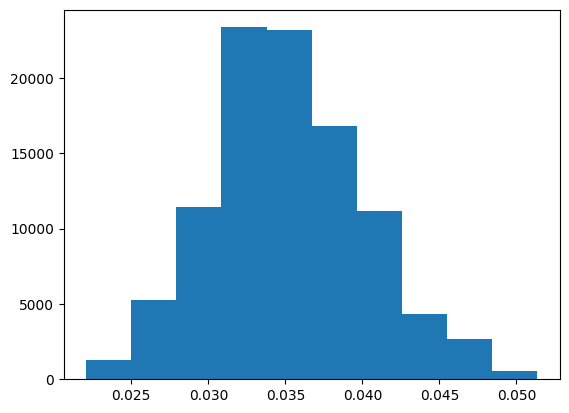

In [148]:
plt.hist(full_samples_fixed_latent[-100000:].T[0])

In [149]:
list(mixture.get_params().keys())[:10]

['0_TtoI_spread',
 '0_TtoII_spread',
 '0_TtoIII_spread',
 '0_TtoIV_spread',
 '0_TtoV_spread',
 '0_ItoII_spread',
 '0_IItoIII_spread',
 '0_IIItoIV_spread',
 '0_IVtoV_spread',
 '0_late_p']

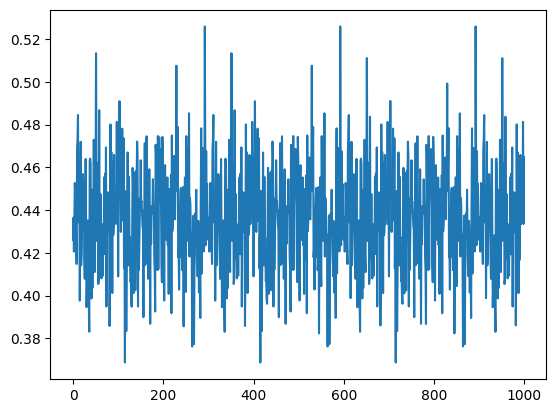

In [153]:
import matplotlib.pyplot as plt
plt.plot(full_samples_fixed_latent[-1000:, 1])

(array([2.550e+02, 9.850e+02, 2.004e+03, 3.752e+03, 3.580e+03, 2.821e+03,
        4.870e+02, 2.860e+02, 1.130e+02, 3.000e+00]),
 array([0.3808251 , 0.39281686, 0.40480862, 0.41680037, 0.42879213,
        0.44078389, 0.45277565, 0.46476741, 0.47675916, 0.48875092,
        0.50074268]),
 <BarContainer object of 10 artists>)

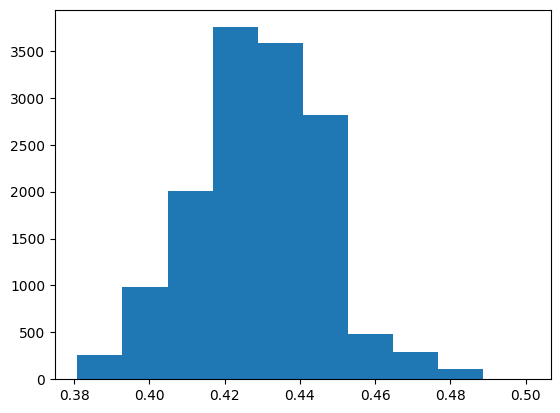

In [154]:
plt.hist(full_samples_fixed_latent[-1000000::70][:,1])

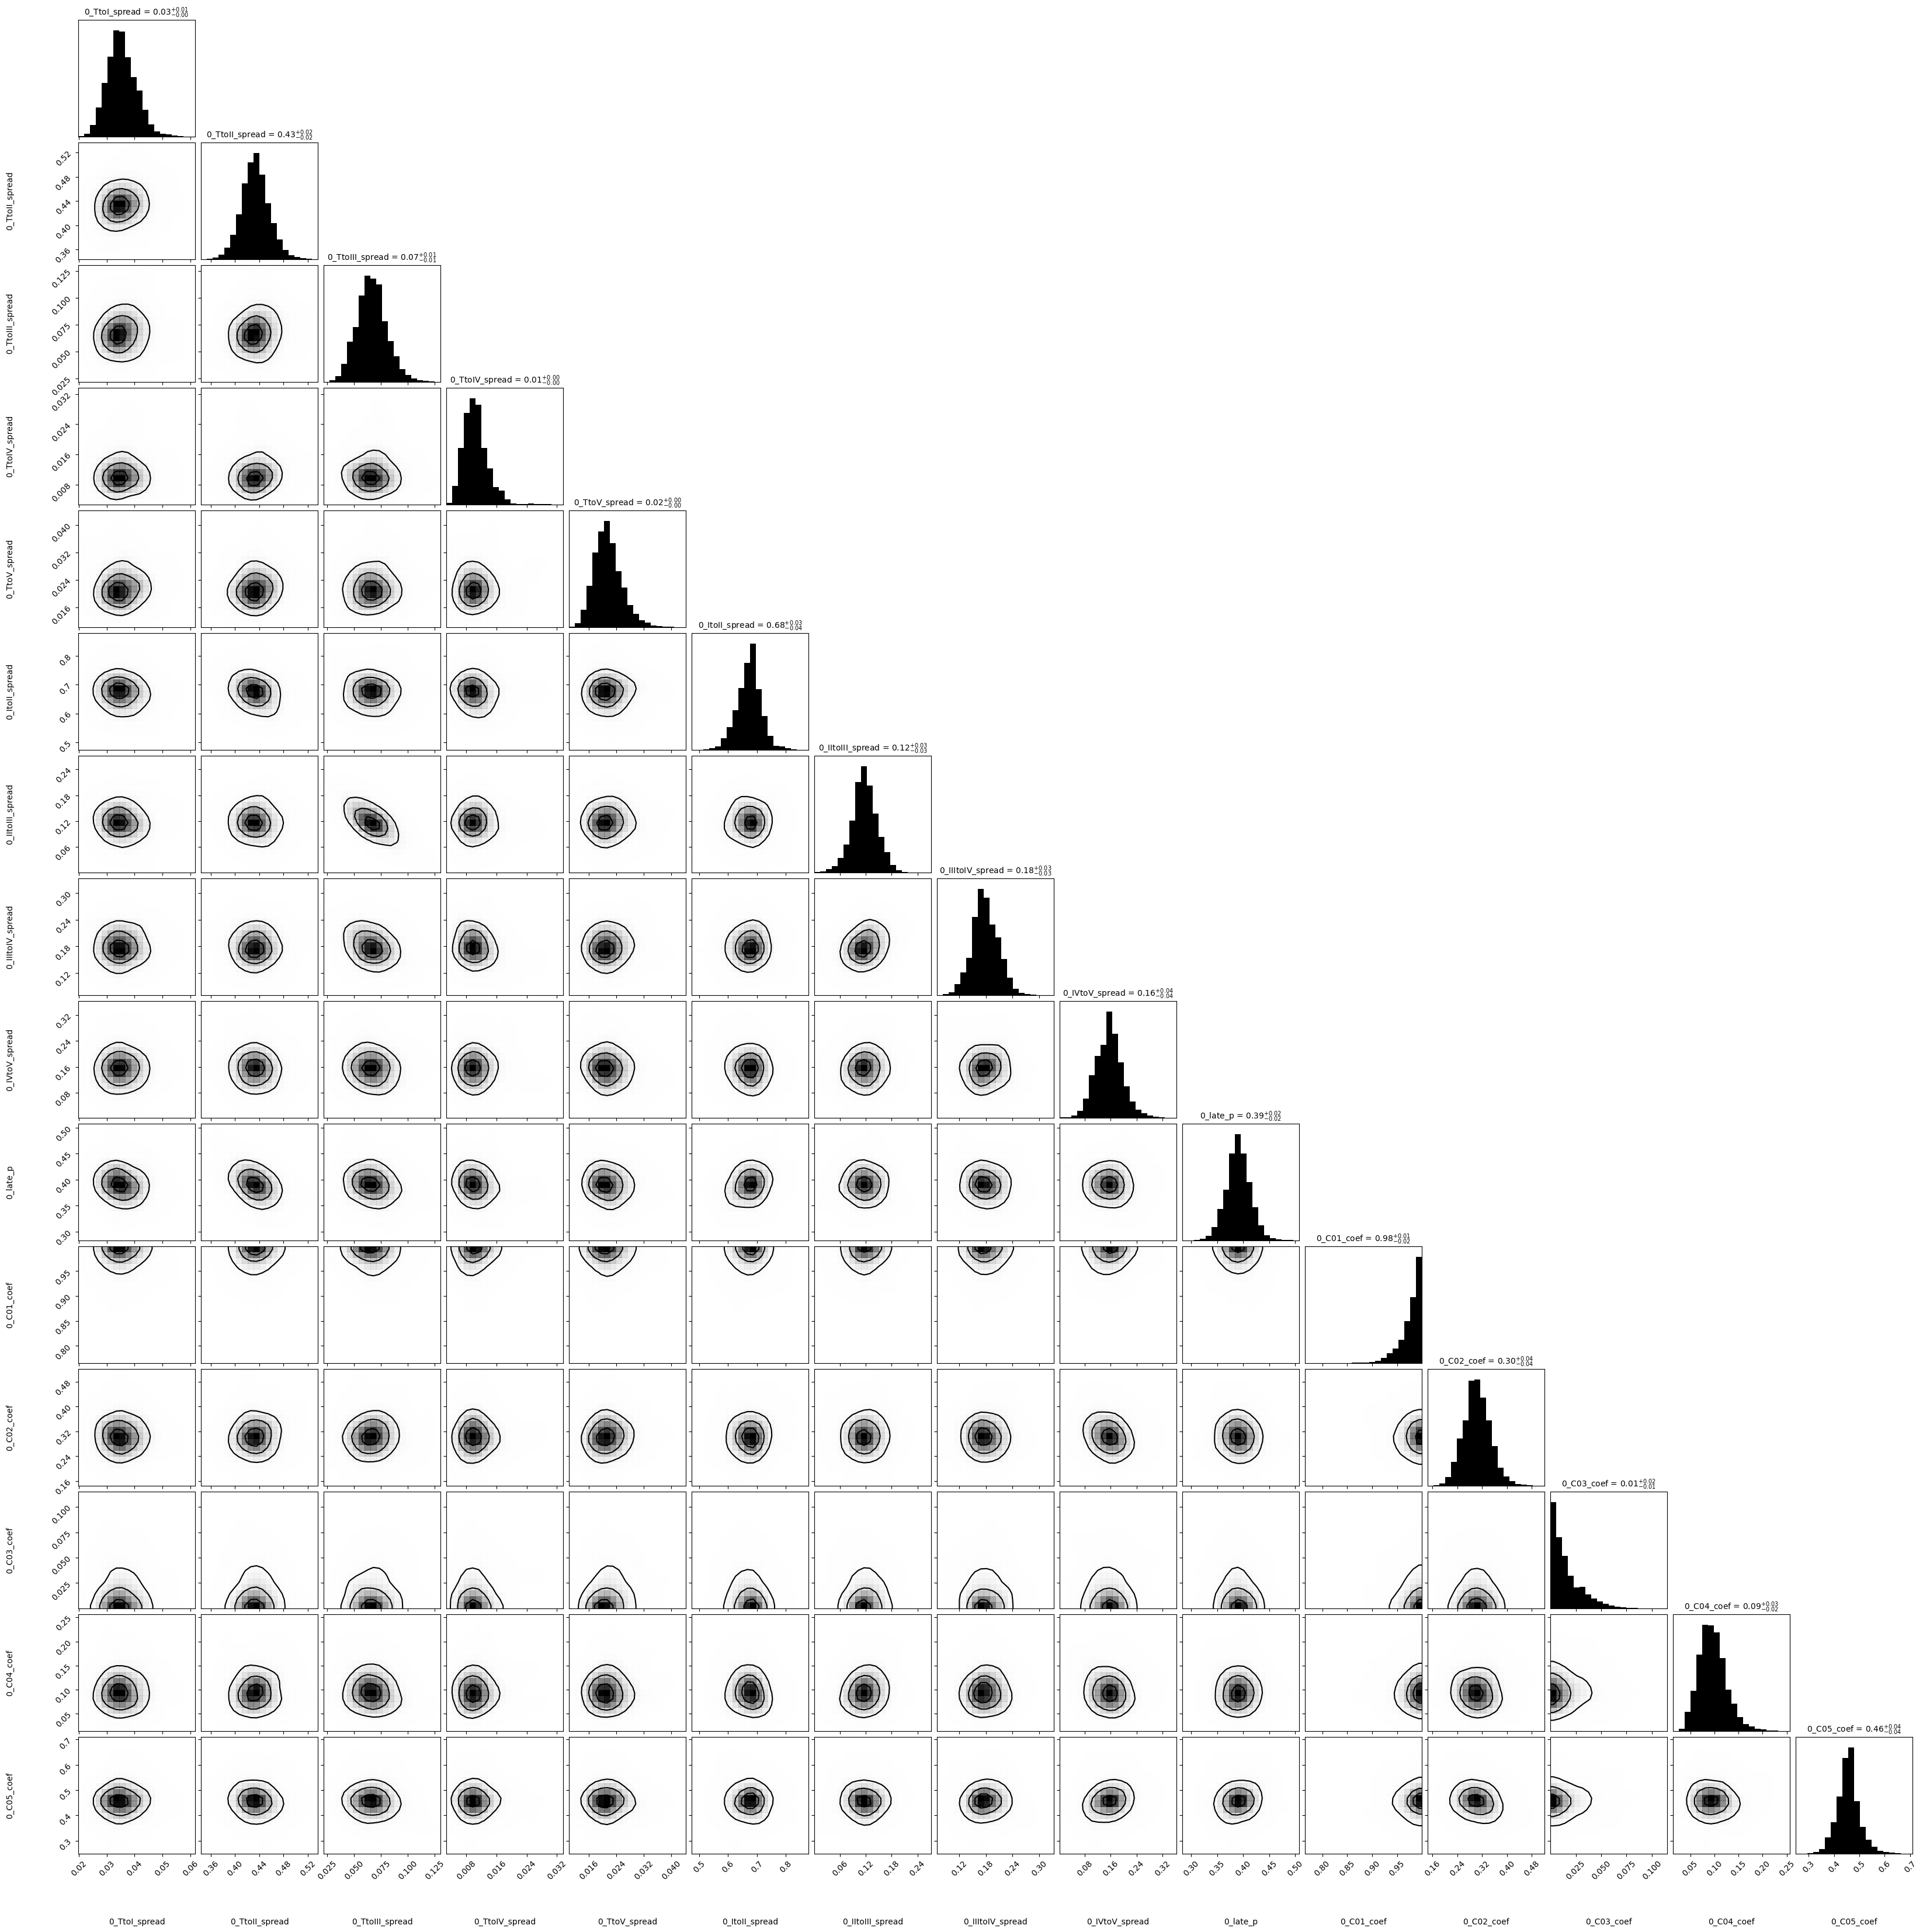

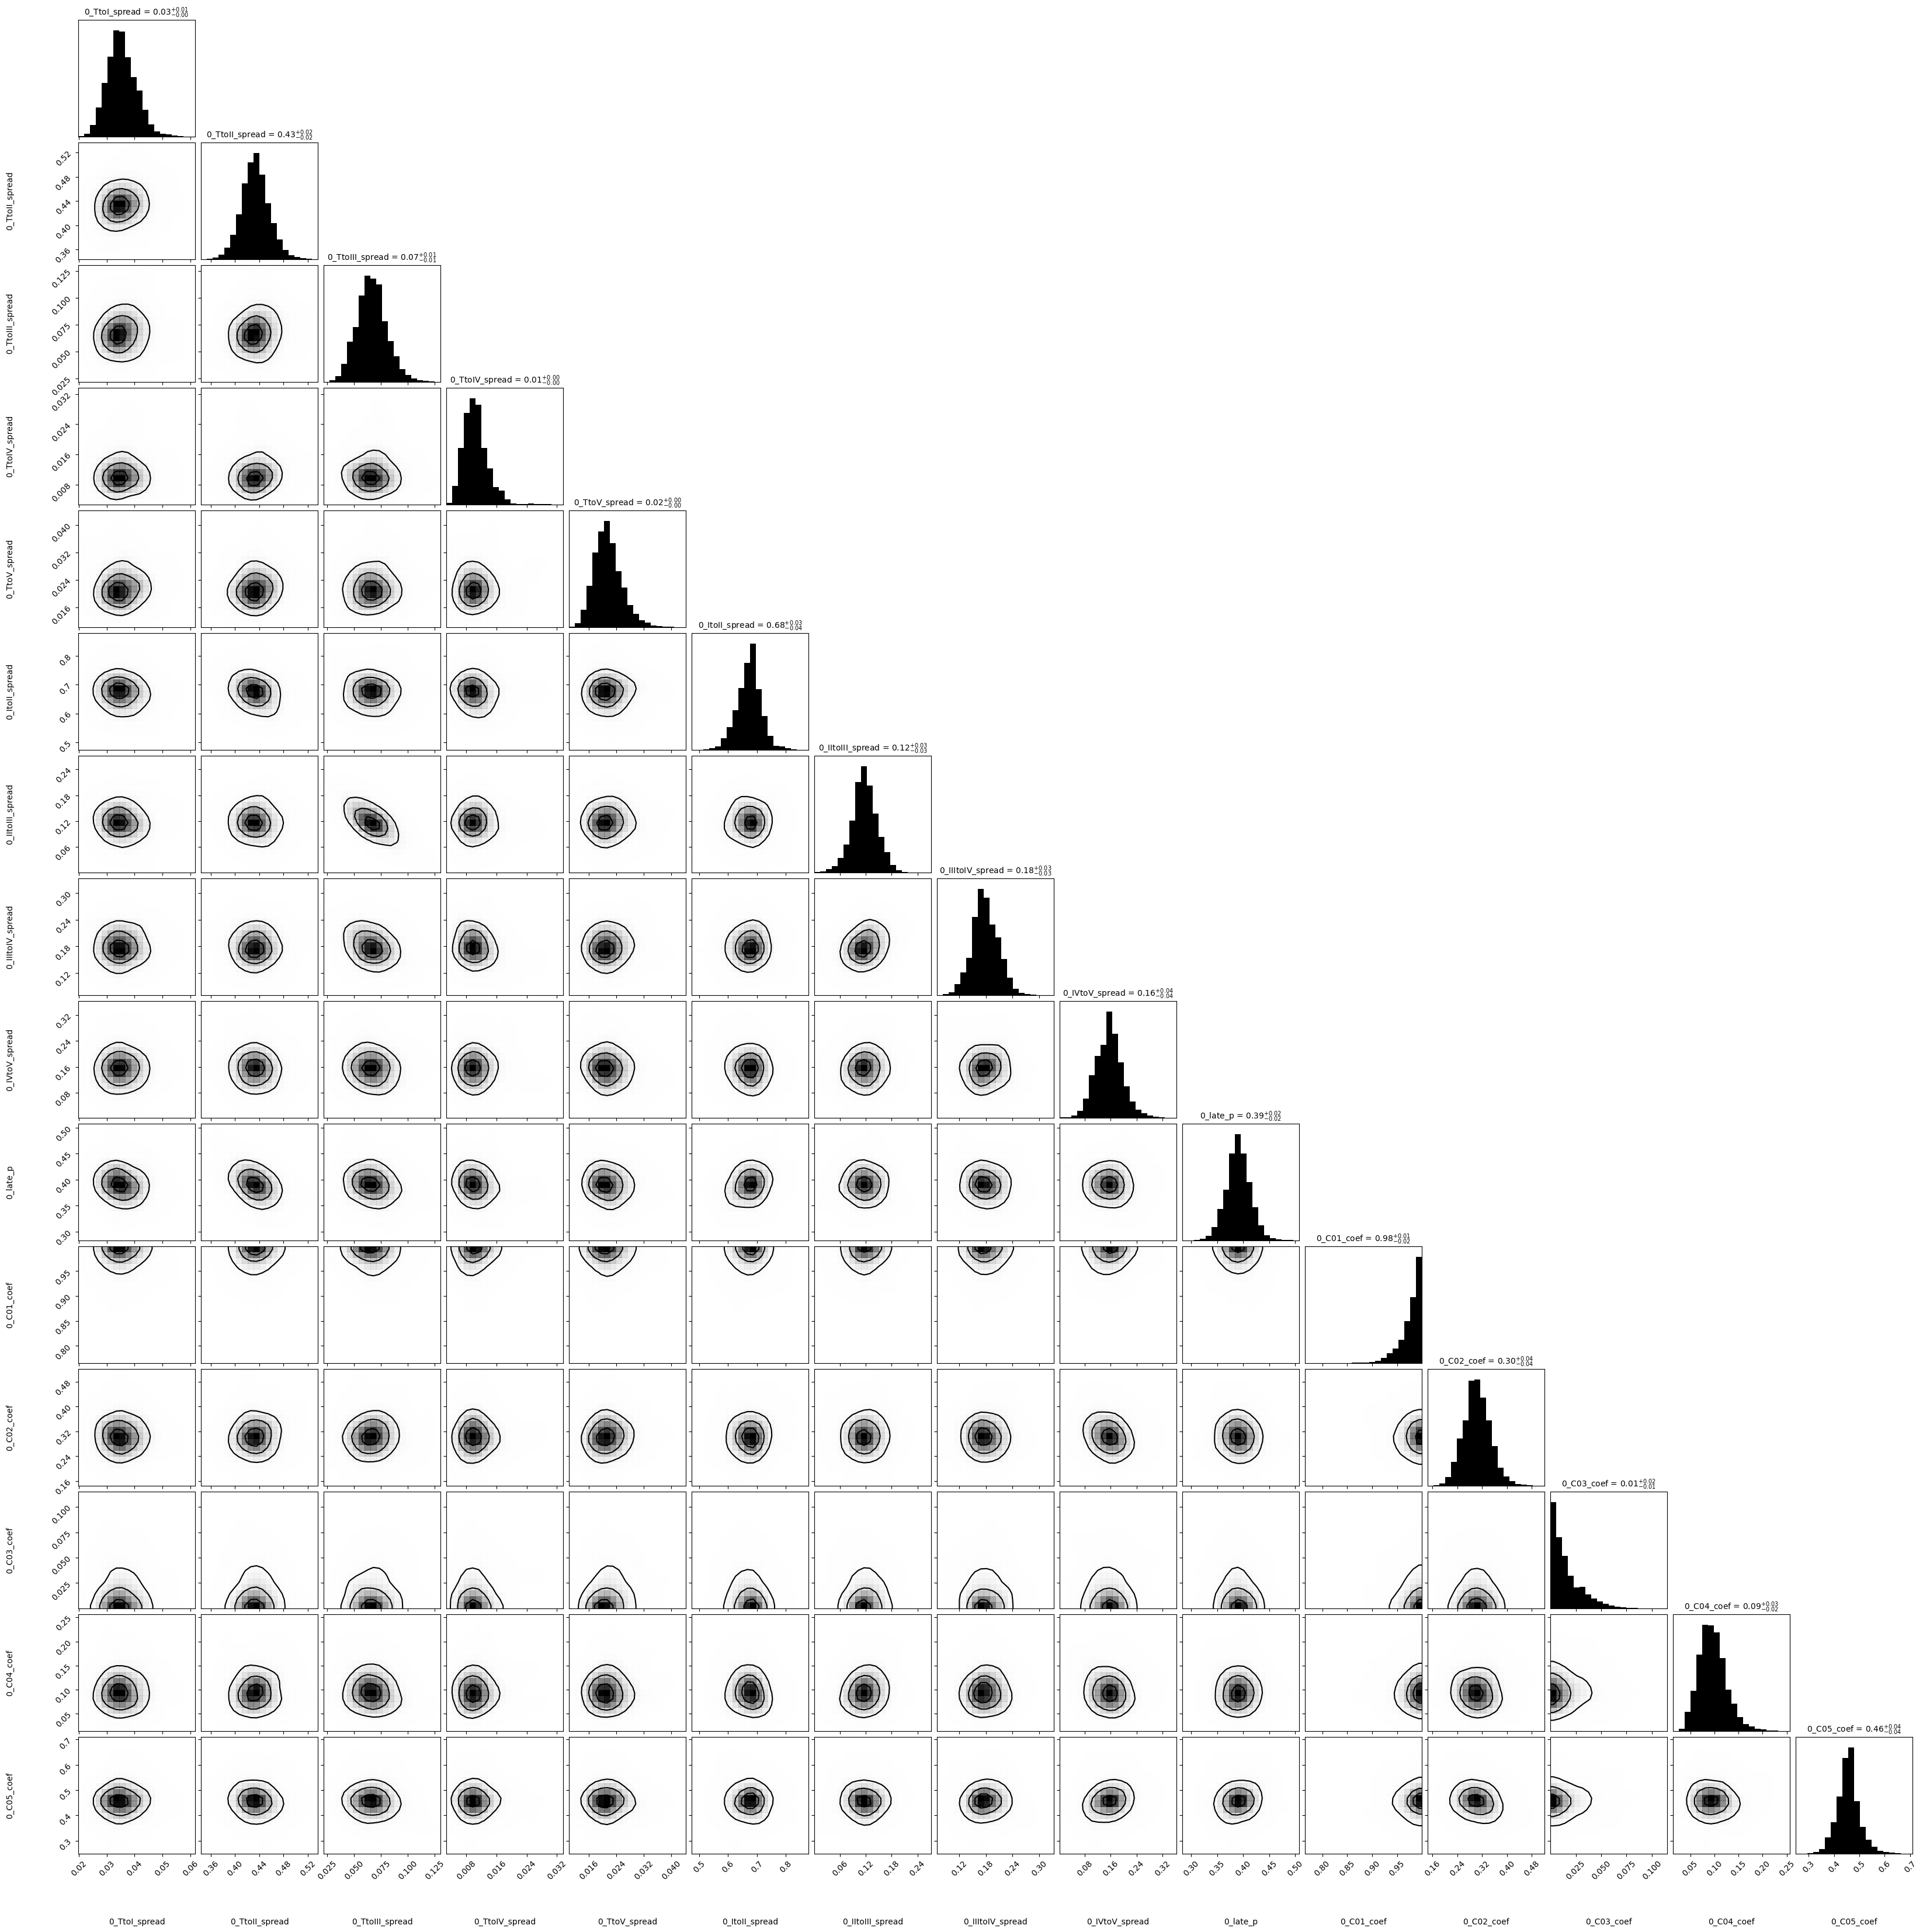

In [155]:
import corner
corner.corner(full_samples_fixed_latent[-1000000:,:15], labels = list(mixture.get_params().keys())[:15], smooth = True, hist_kwargs = {'histtype':'stepfilled'},**{'plot_datapoints':False,'no_fill_contours':True, 'levels': np.array([0.2,0.5,0.8])},show_titles = True, title_kwargs={"fontsize": 10},labelpad = 0.25)

In [53]:
component_list = list(range(len(mixture.components)))
component_dictionary_early_full_sampling = {}
for component in component_list:
        component_dictionary_early_full_sampling[str(component)] = {
            'I': [],
            'II': [],
            'III': [],
            'IV': [],
            'V': []
        }

involvement_I = {'I': True}
involvement_II = {'II': True}
involvement_III = {'III': True}
involvement_IV = {'IV': True}
involvement_V = {'V': True}

In [56]:
for component in component_list:
    risk_dictionary = {
        'I': [],
        'II': [],
        'III': [],
        'IV': [],
        'V': []
    }
    for sample in full_samples_fixed_latent[::9000]:
        mixture.set_params(*sample)
        risk_dictionary['I'].append(mixture.components[component].risk(involvement = involvement_I, t_stage = 'early'))
        risk_dictionary['II'].append(mixture.components[component].risk(involvement = involvement_II, t_stage = 'early'))
        risk_dictionary['III'].append(mixture.components[component].risk(involvement = involvement_III, t_stage = 'early'))
        risk_dictionary['IV'].append(mixture.components[component].risk(involvement = involvement_IV, t_stage = 'early'))
        risk_dictionary['V'].append(mixture.components[component].risk(involvement = involvement_V, t_stage = 'early'))
        if len(risk_dictionary['II'])%1000 == 0:
            print('1k done')
    component_dictionary_early_full_sampling[str(component)] = risk_dictionary

In [55]:
subsite_dictionary_full_sampling = {}
subsite_dictionary_early_full_sampling = {}
subsite_list = list(mixture.subgroups.keys())
for subsite in subsite_list:
    subsite_dictionary_early_full_sampling[subsite] = {
        'I': [],
        'II': [],
        'III': [],
        'IV': [],
        'V': []
    }

involvement_I = {'I': True}
involvement_II = {'II': True}
involvement_III = {'III': True}
involvement_IV = {'IV': True}
involvement_V = {'V': True}

In [56]:
(full_samples_fixed_latent).shape

(3617100, 60)

In [59]:
# Loop through samples first
for sample in full_samples_fixed_latent[-1000000:][::3000]:
    mixture.set_params(*sample)
    print(mixture.likelihood())
    for subsite in subsite_list:
        risk_dictionary = subsite_dictionary_early_full_sampling[subsite]
        
        # Append risk values to the respective keys
        risk_dictionary['I'].append(mixture.risk(subgroup=subsite, involvement=involvement_I, t_stage='early'))
        risk_dictionary['II'].append(mixture.risk(subgroup=subsite, involvement=involvement_II, t_stage='early'))
        risk_dictionary['III'].append(mixture.risk(subgroup=subsite, involvement=involvement_III, t_stage='early'))
        risk_dictionary['IV'].append(mixture.risk(subgroup=subsite, involvement=involvement_IV, t_stage='early'))
        risk_dictionary['V'].append(mixture.risk(subgroup=subsite, involvement=involvement_V, t_stage='early'))
        

-3668.640375411545
-3676.6698976710873
-3676.6698976710873
-3669.49104375758
-3668.142185608168
-3680.0388147974177
-3674.45878590152
-3674.7169729168327
-3674.7169729168327
-3674.7169729168327
-3672.706536944649
-3670.2927342060043
-3670.2927342060043
-3672.4012897927682
-3670.4226317304997
-3669.873244567555
-3666.9422242904134
-3666.9422242904134
-3666.9422242904134
-3666.9422242904134
-3666.9422242904134
-3668.2828678422197
-3668.2828678422197
-3668.2828678422197
-3668.2828678422197
-3668.2828678422197
-3668.2828678422197
-3668.2828678422197
-3668.2828678422197
-3668.2828678422197
-3668.2828678422197
-3668.2828678422197
-3668.2828678422197
-3662.107571860715
-3662.107571860715
-3665.388733410325
-3665.388733410325
-3664.728150718852
-3672.6959389335416
-3669.325323361644
-3669.325323361644
-3668.3384553741753
-3668.9976089692955
-3668.9976089692955
-3670.296279195052
-3670.296279195052
-3670.296279195052
-3670.296279195052
-3670.296279195052
-3670.296279195052
-3664.2503401463673
-

KeyboardInterrupt: 

In [60]:
from cycler import cycler
import scipy as sp
def multiple_plotter(dataset, risk_dictionary, subsite, stage = ''):
    COLORS = {"green": '#00afa5',
        "blue": '#005ea8',
        "orange": '#f17900',
        "red": '#ae0060',
        "gray": '#c5d5db',
    }
    hist_cycl = (
        cycler(histtype=["stepfilled", "step"])
        * cycler(color=list(COLORS.values()))
    )
    line_cycl = (
        cycler(linestyle=["-", "--"])
        * cycler(color=list(COLORS.values()))
    )
    if stage == 'early' or stage == 'late':
        data_selected = dataset.loc[(dataset['tumor']['1']['subsite'] == subsite) & (dataset['tumor']['1']['t_stage'] == stage)]  
    else:
        data_selected = dataset.loc[dataset['tumor']['1']['subsite'] == subsite]
    min_value = 0
    max_value = 100
    prevalence = {}
    number_of_patients = {}
    risks = {}
    for key in risk_dictionary.keys():
        prevalence[key] = (data_selected['diagnostic_consensus']['ipsi'][key] == True).sum()
        number_of_patients[key] = len(data_selected)
        risks[key] = np.array(risk_dictionary[key])*100
    
    num_matches = [prevalence[key] for key in risk_dictionary.keys()]
    num_totals = [number_of_patients[key] for key in risk_dictionary.keys()]
    values = [risks[key] for key in risk_dictionary.keys()]
    hist_kwargs = {
                "bins": np.linspace(min_value, max_value, 80),
                "density": True,
                "alpha": 0.6,
                "linewidth": 2.,
            }
    fig, ax = plt.subplots(figsize=(12,4))

    x = np.linspace(min_value, max_value, 200)
    zipper = zip(values, risk_dictionary.keys(), num_matches, num_totals, hist_cycl, line_cycl)
    for vals, label, a, n, hstyle, lstyle in zipper:
        ax.hist(
            vals,
            label=label,
            **hist_kwargs,
            **hstyle
        )
        if not np.isnan(a):
            post = sp.stats.beta.pdf(x / 100., a+1, n-a+1) / 100.
            ax.plot(x, post, label=f"{int(a)}/{int(n)}", **lstyle)
        ax.legend()
        ax.set_xlabel("probability [%]")
    plt.suptitle(f"Risk distributions {stage} for subsite {subsite}",fontsize = 16)
    

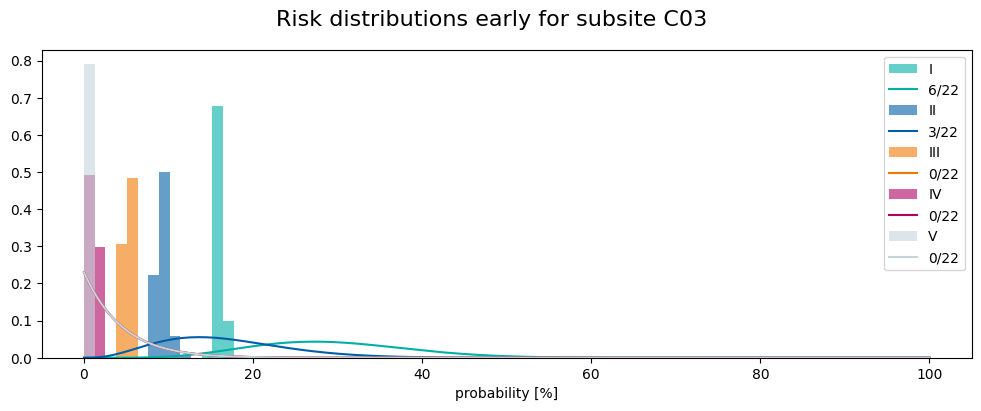

In [65]:
multiple_plotter(dataset= dataset_staging_main_groups, risk_dictionary = subsite_dictionary_early_full_sampling['C03'], subsite = 'C03', stage = 'early' )

In [62]:
mixture.risk(subgroup = 'C02', t_stage = 'early', involvement = {'I': None, 'II': None, 'III': None, 'IV': None, 'V': True})

0.03208518050215082

(array([ 6.,  1., 34., 45., 82., 48., 29., 16.,  5., 10.]),
 array([0.14097578, 0.1424386 , 0.14390142, 0.14536424, 0.14682706,
        0.14828988, 0.14975271, 0.15121553, 0.15267835, 0.15414117,
        0.15560399]),
 <BarContainer object of 10 artists>)

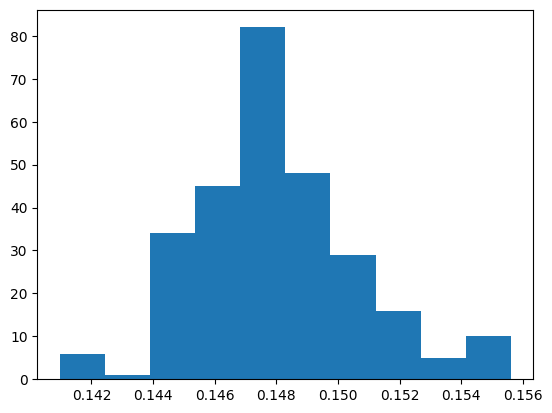

In [63]:
plt.hist(subsite_dictionary_early_full_sampling['C02']['III'])

## fixed mixture

In [7]:
from lymixture.em import sample_fixed_mixture

backend_fixed_mixture, samples_fixed_mixture = sample_fixed_mixture(mixture, steps = 2, latent = None, continue_sampling = True)


100%|██████████| 2/2 [00:28<00:00, 14.30s/it]


In [8]:
backend_fixed_mixture, samples_fixed_mixture = sample_fixed_mixture(mixture, steps = 10000, latent = None, continue_sampling = False, filename = 'fixed_mixture_3_comp_3_no_VI_VII_new.hdf5')

100%|██████████| 10000/10000 [37:13:06<00:00, 13.40s/it]  


In [9]:
samples_fixed_mixture.shape

(150000, 30)

In [10]:
full_samples_fixed_mixture = backend_fixed_mixture.get_chain(flat = True)

In [11]:
full_samples_fixed_mixture[0]

array([3.44825918e-02, 4.34431531e-01, 6.97959345e-02, 9.90529549e-03,
       2.00980953e-02, 6.82658274e-01, 1.06489596e-01, 1.69467695e-01,
       1.57339658e-01, 3.90714213e-01, 6.12325564e-02, 2.65794619e-02,
       1.38416276e-02, 4.07173767e-03, 6.70898055e-05, 1.63942681e-01,
       4.63875721e-02, 1.72385516e-02, 6.61522618e-05, 6.95983556e-01,
       1.20239604e-02, 2.82427527e-01, 1.41082982e-01, 4.65659775e-02,
       2.93861138e-02, 6.09110903e-01, 2.87480570e-01, 8.15888180e-02,
       9.95615070e-02, 3.73678881e-01])

(array([ 32432.,  40923.,  82428., 182538., 447795., 275420., 187869.,
        109103.,  76545.,  64947.]),
 array([7.28690768e-05, 1.00064787e-01, 2.00056705e-01, 3.00048623e-01,
        4.00040541e-01, 5.00032459e-01, 6.00024376e-01, 7.00016294e-01,
        8.00008212e-01, 9.00000130e-01, 9.99992048e-01]),
 <BarContainer object of 10 artists>)

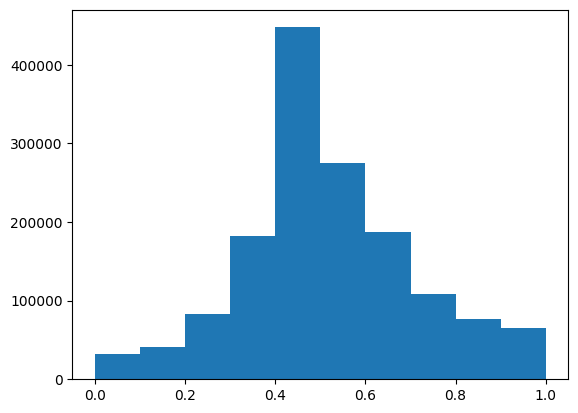

In [12]:
import matplotlib.pyplot as plt
plt.hist(full_samples_fixed_mixture.T[1])

In [13]:
indices = [i for i, key in enumerate(mixture.get_params().keys()) if 'coef' in key]
labels = np.array(list(mixture.get_params().keys()))[~np.array(indices)][::-1]

In [14]:
full_samples_fixed_mixture.T.shape

(30, 1500000)

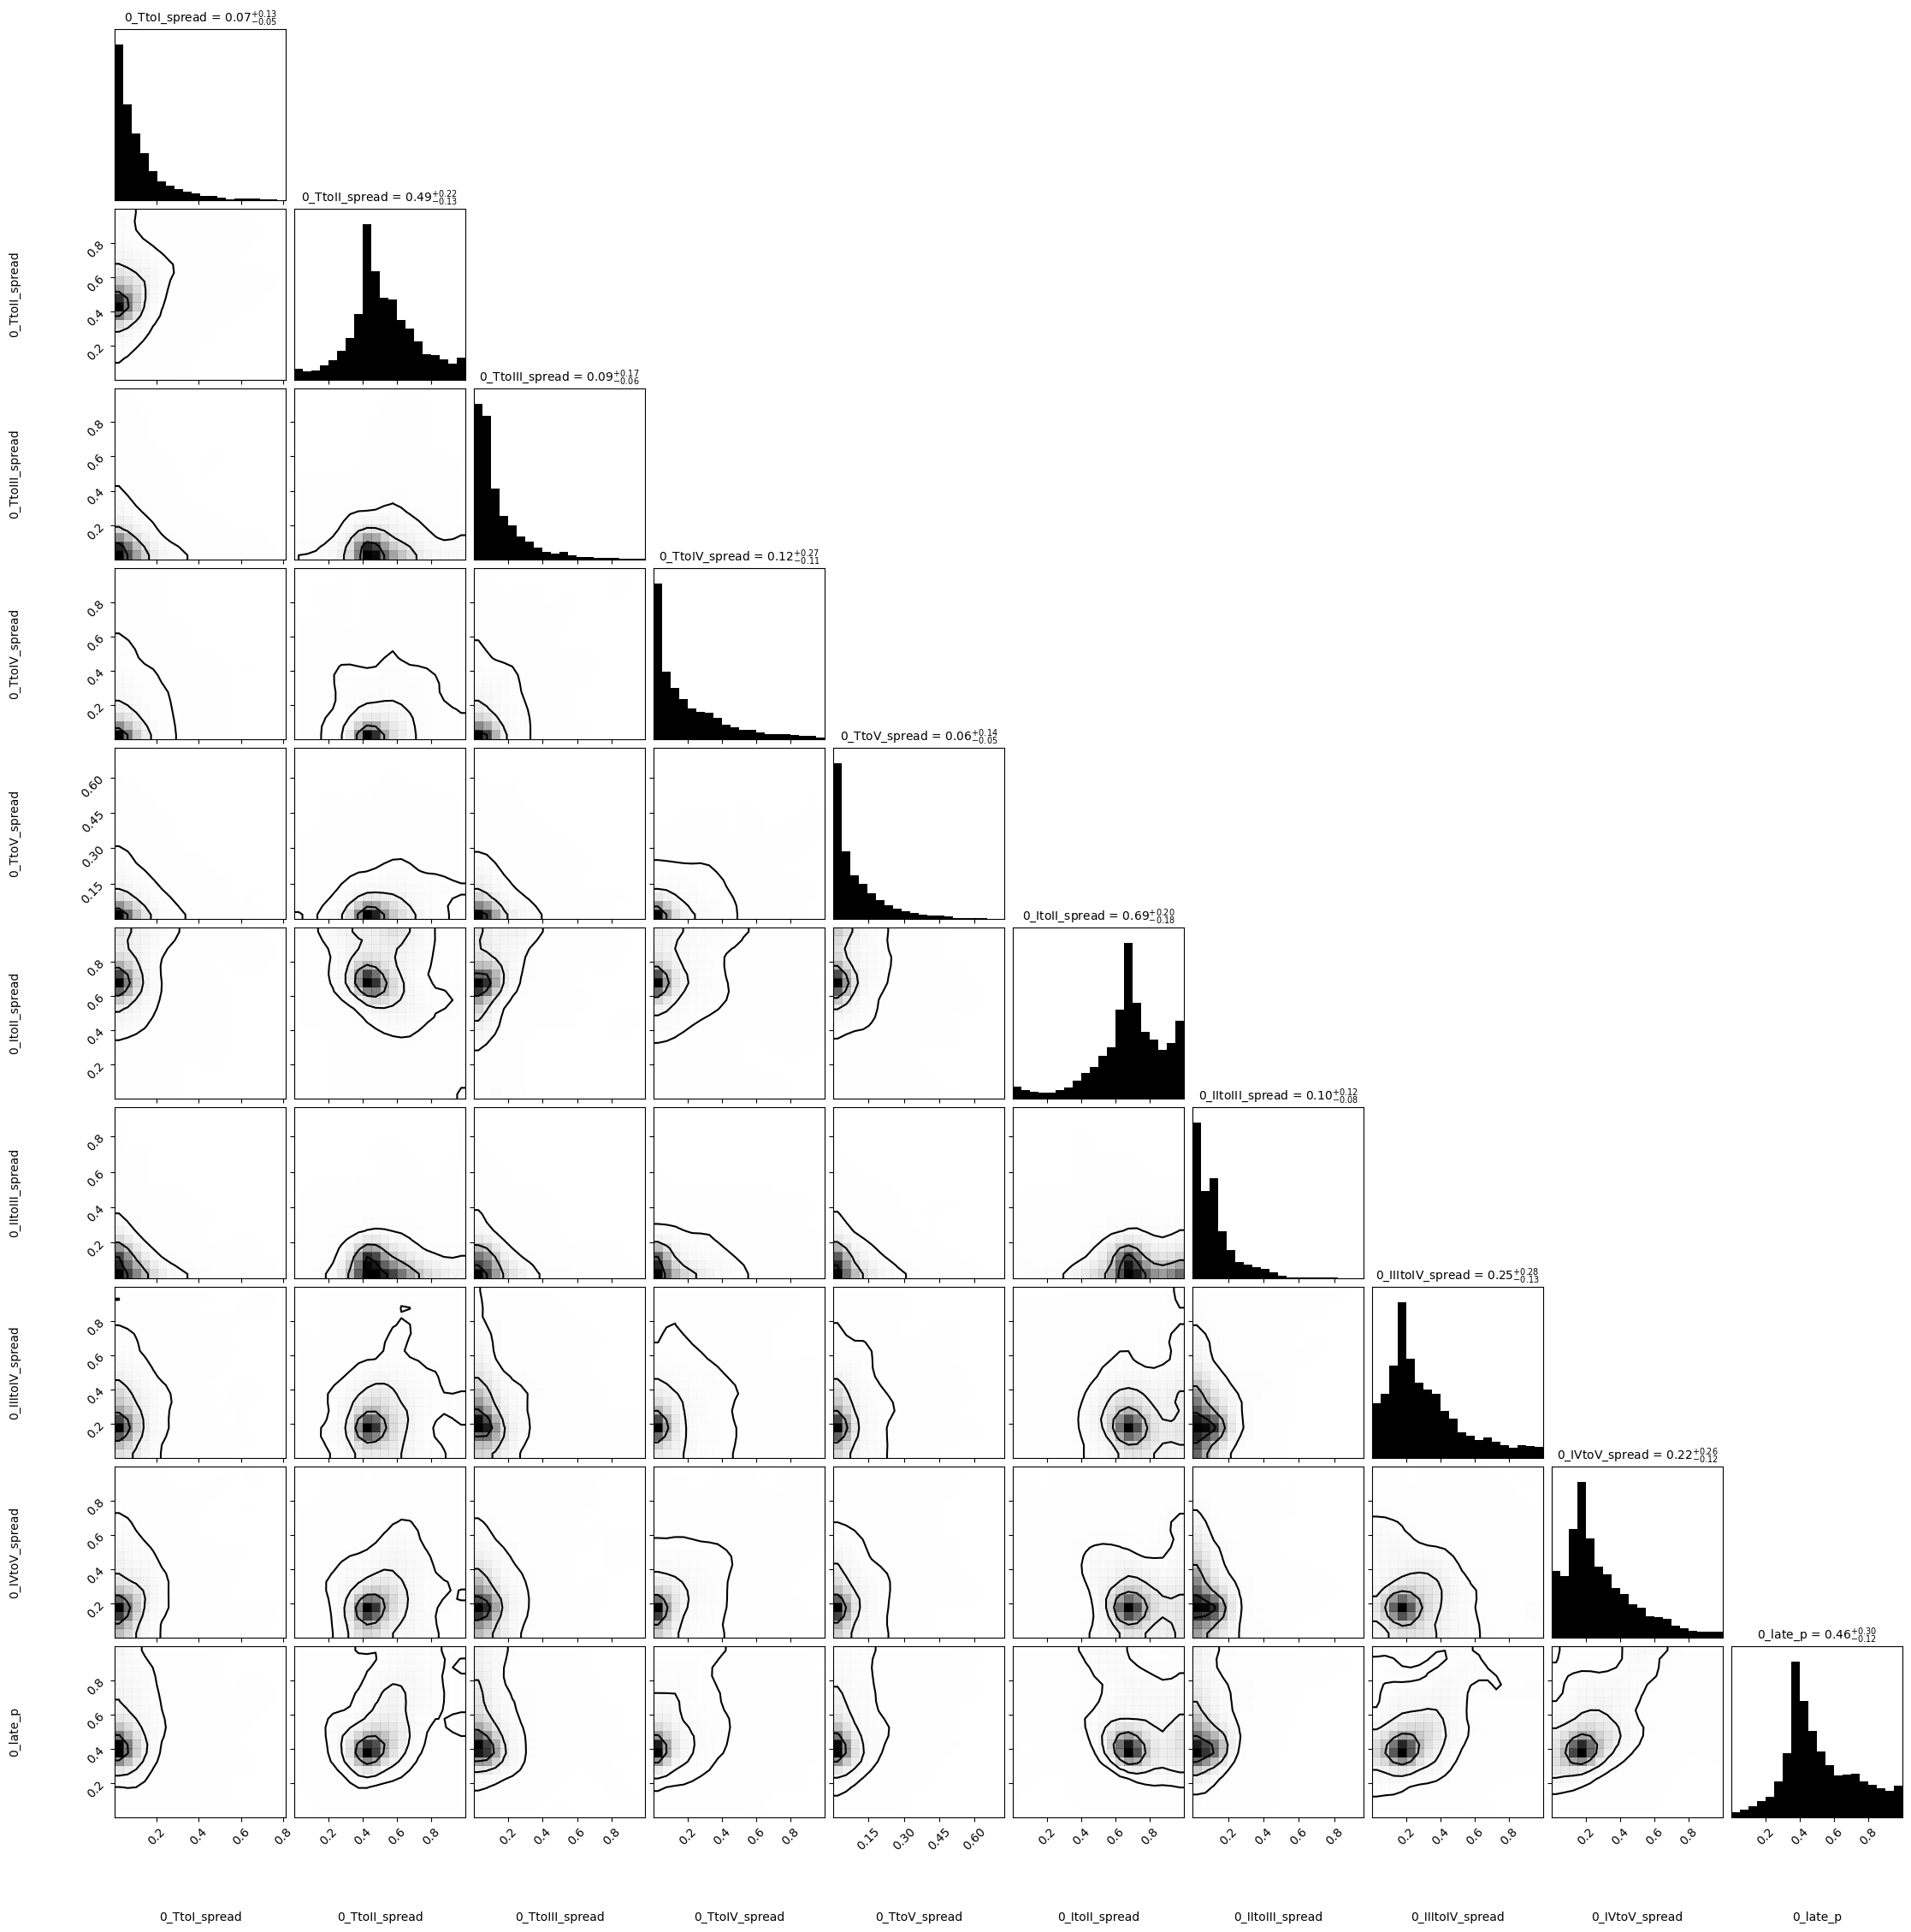

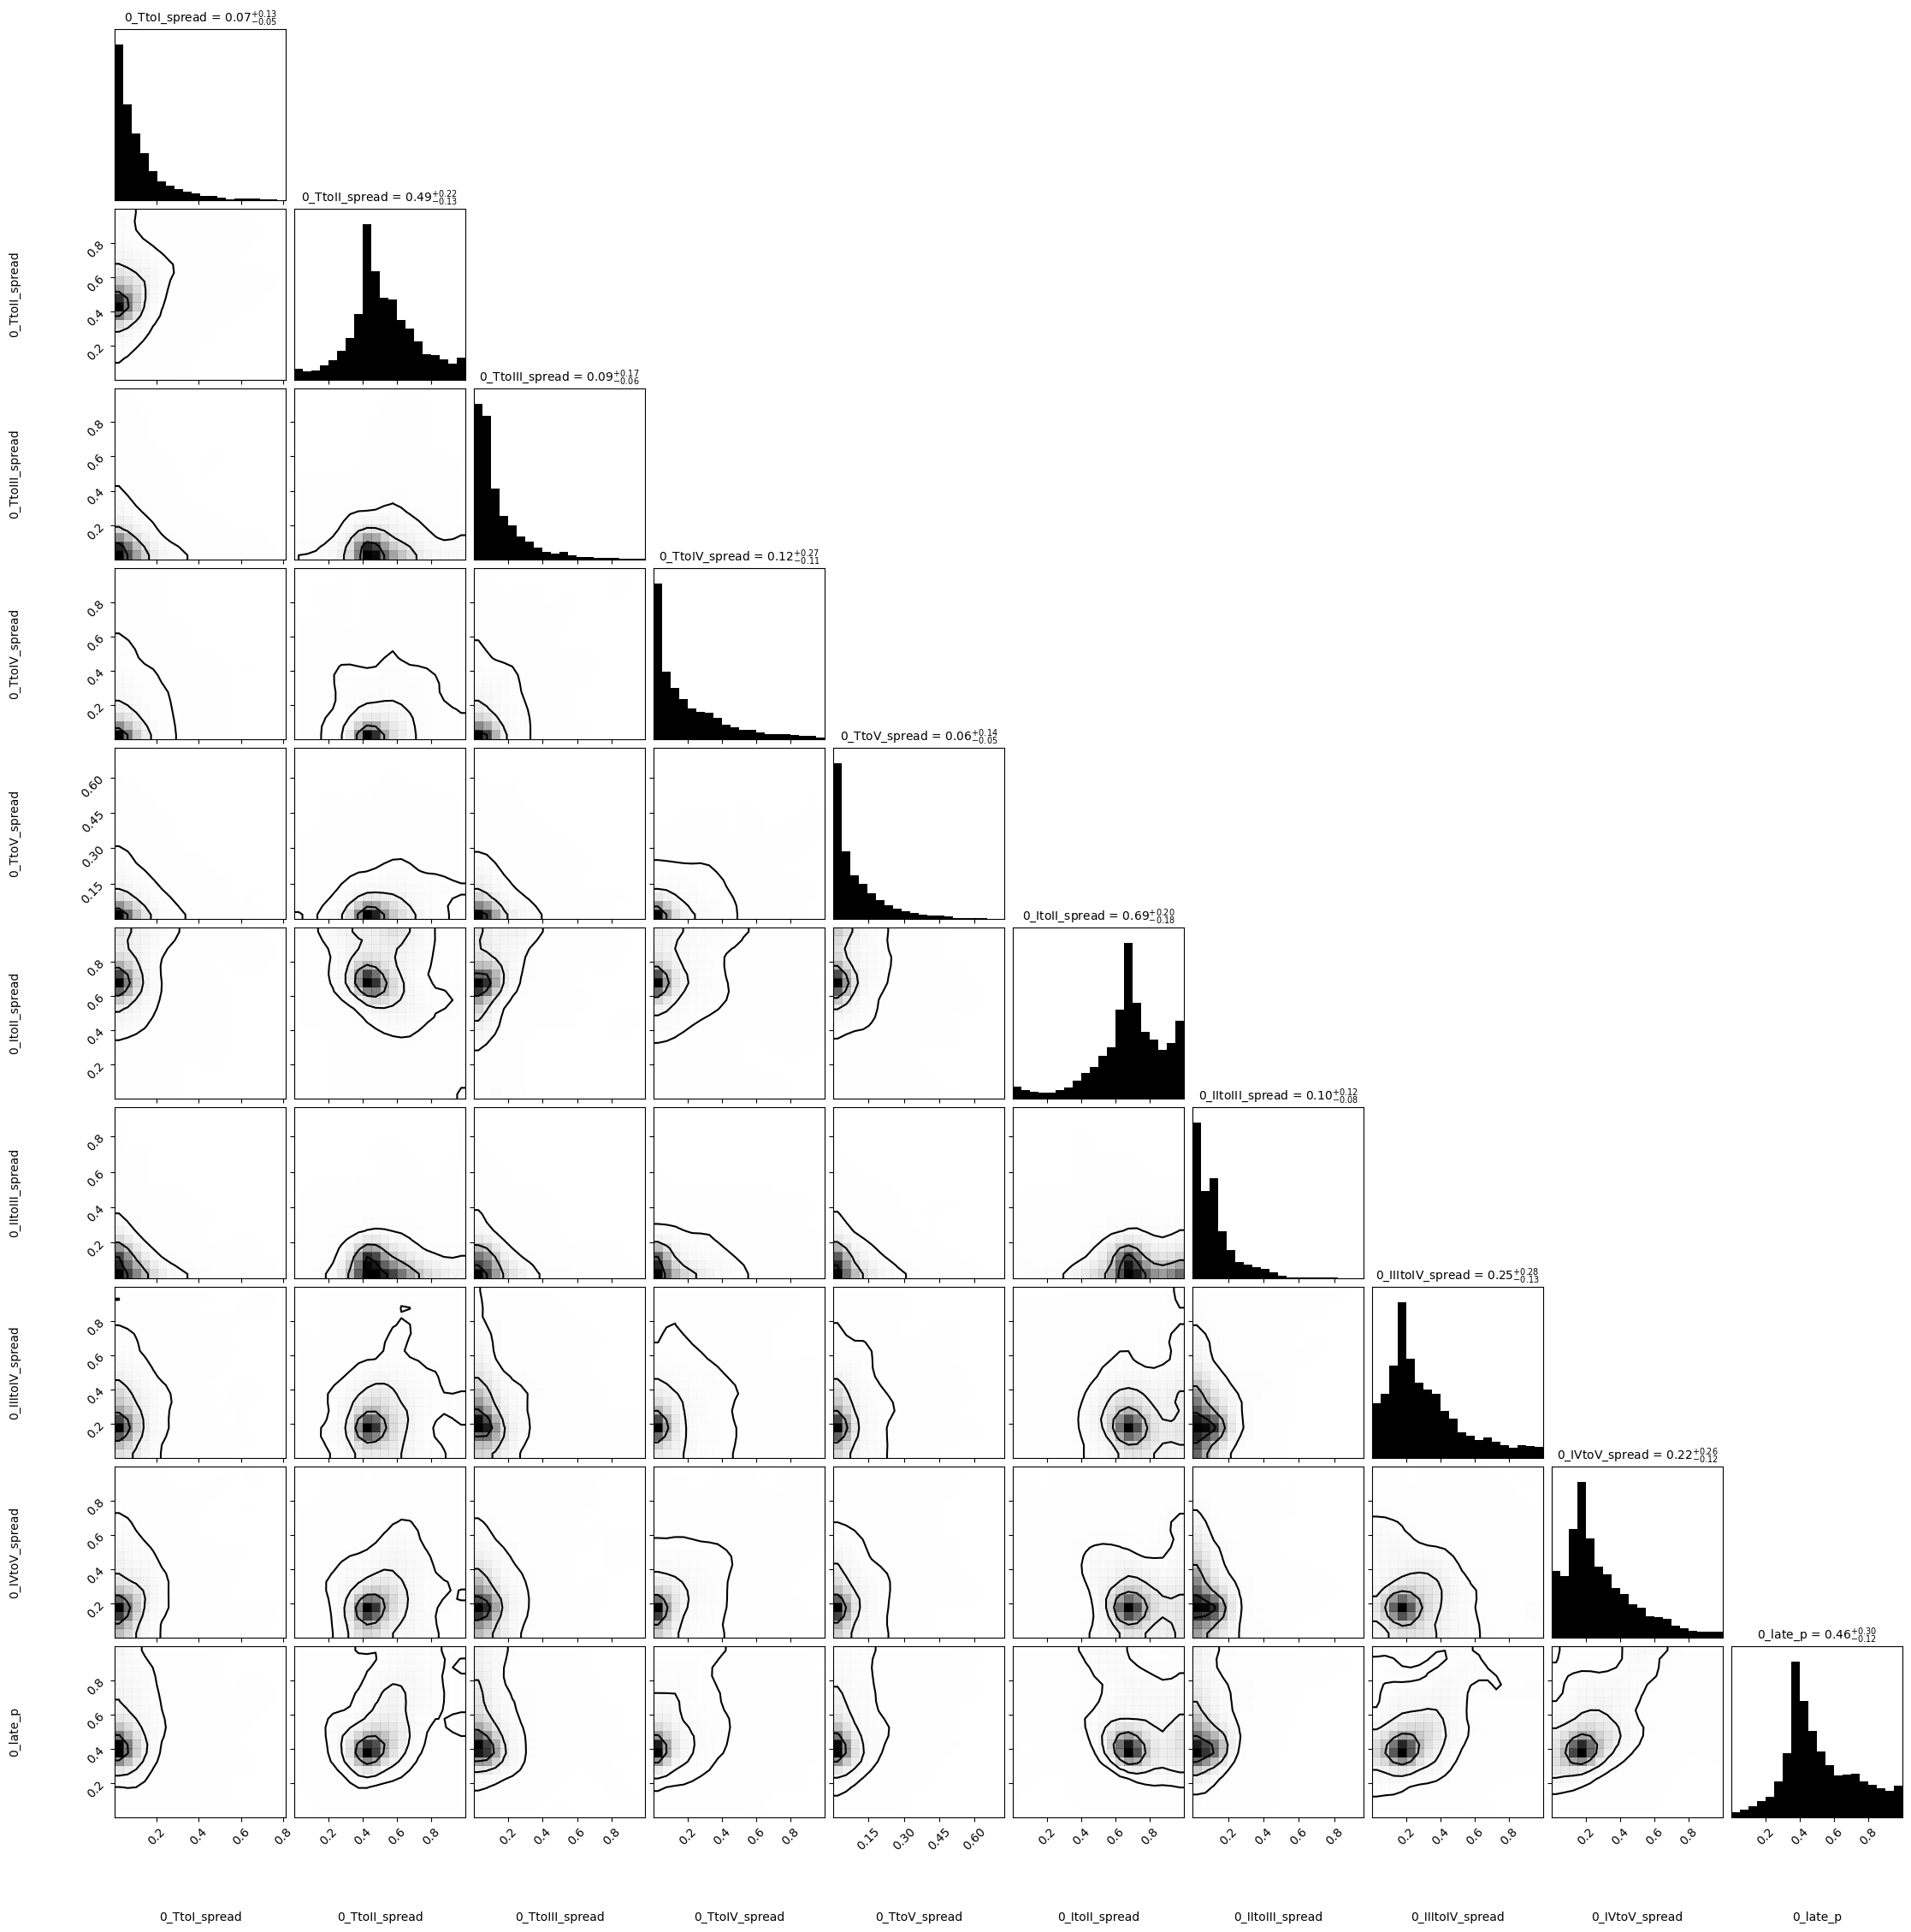

In [15]:
import corner
corner.corner(full_samples_fixed_mixture[:,:10], labels = labels, smooth = True, hist_kwargs = {'histtype':'stepfilled'},**{'plot_datapoints':False,'no_fill_contours':True, 'levels': np.array([0.2,0.5,0.8])},show_titles = True, title_kwargs={"fontsize": 10},labelpad = 0.25)

In [85]:
subsite_dictionary_fixed_mixture = {}
subsite_dictionary_late_fixed_mixture = {}
subsite_list = list(mixture.subgroups.keys())

In [86]:
subsite_list

['C01', 'C02', 'C03', 'C04', 'C05', 'C06', 'C09', 'C10', 'C12', 'C13']

In [ ]:
for subsite in subsite_list:
    # subsite = 'C02'
    risk_dictionary = {
        'I': [],
        'II': [],
        'III': [],
        'IV': [],
        'V': []
    }
    for sample in full_samples_fixed_mixture[::70]:
        mixture.set_params(*sample)
        risk_dictionary['I'].append(mixture.risk(subgroup = subsite, involvement = involvement_I, t_stage = 'late'))
        risk_dictionary['II'].append(mixture.risk(subgroup = subsite, involvement = involvement_II, t_stage = 'late'))
        risk_dictionary['III'].append(mixture.risk(subgroup = subsite, involvement = involvement_III, t_stage = 'late'))
        risk_dictionary['IV'].append(mixture.risk(subgroup = subsite, involvement = involvement_IV, t_stage = 'late'))
        risk_dictionary['V'].append(mixture.risk(subgroup = subsite, involvement = involvement_V, t_stage = 'late'))
        if len(risk_dictionary['II'])%1000 == 0:
            print('1k done')
    subsite_dictionary_late[subsite] = risk_dictionary

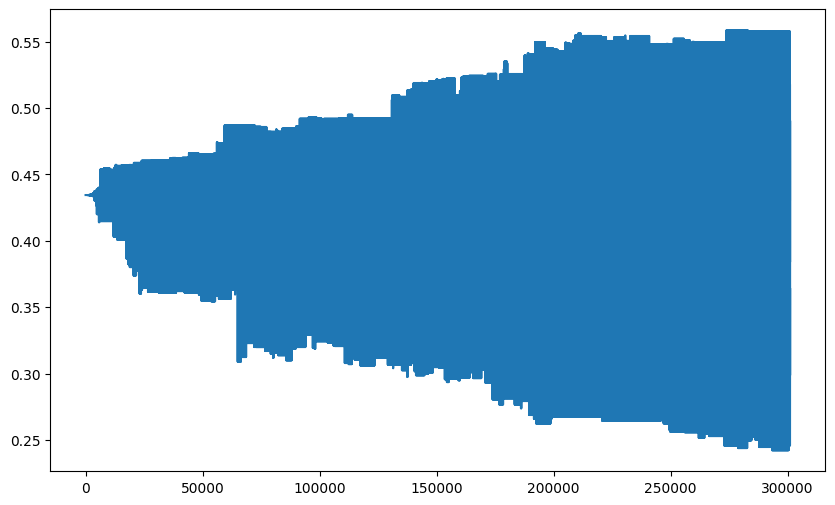

In [142]:
plt.figure(figsize=(10, 6))
plt.plot(full_samples_fixed_mixture[-1000000:, 1], label='Original Samples')



### back to latent

In [67]:
full_samples = np.load('samples_3_component_fixed_latent.npy')

In [74]:
full_samples.shape

(500000, 60)

(array([  27.,  175.,  556., 1357., 2234., 1550.,  683.,  381.,  167.,
          13.]),
 array([0.37224245, 0.38717499, 0.40210753, 0.41704008, 0.43197262,
        0.44690516, 0.46183771, 0.47677025, 0.49170279, 0.50663534,
        0.52156788]),
 <BarContainer object of 10 artists>)

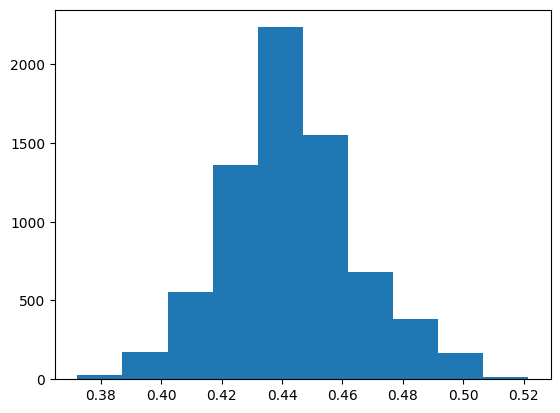

In [68]:
plt.hist(full_samples[::70][:,1])

In [69]:
involvement_I = {'I': True}
involvement_II = {'II': True}
involvement_III = {'III': True}
involvement_IV = {'IV': True}
involvement_V = {'V': True}

In [70]:
mixture.set_params(*full_samples[0])
mixture.risk(subgroup = 'C01', involvement = involvement_II)

0.7403935896534263

In [71]:
len(full_samples)
len(full_samples[::70])

7143

In [72]:
subsite_dictionary = {}
subsite_dictionary_late = {}
subsite_list = list(mixture.subgroups.keys())

In [73]:
for subsite in subsite_list:
    # subsite = 'C02'
    risk_dictionary = {
        'I': [],
        'II': [],
        'III': [],
        'IV': [],
        'V': []
    }
    for sample in full_samples[::70]:
        mixture.set_params(*sample)
        risk_dictionary['I'].append(mixture.risk(subgroup = subsite, involvement = involvement_I, t_stage = 'late'))
        risk_dictionary['II'].append(mixture.risk(subgroup = subsite, involvement = involvement_II, t_stage = 'late'))
        risk_dictionary['III'].append(mixture.risk(subgroup = subsite, involvement = involvement_III, t_stage = 'late'))
        risk_dictionary['IV'].append(mixture.risk(subgroup = subsite, involvement = involvement_IV, t_stage = 'late'))
        risk_dictionary['V'].append(mixture.risk(subgroup = subsite, involvement = involvement_V, t_stage = 'late'))
        if len(risk_dictionary['II'])%1000 == 0:
            print('1k done')
    subsite_dictionary_late[subsite] = risk_dictionary
        

KeyboardInterrupt: 

In [32]:
import scipy as sp

def plotter(dataset, risks, lnl, subsite):
    data_selected = dataset.loc[dataset['tumor']['1']['subsite'] == subsite]
    prevalence = (data_selected['diagnostic_consensus']['ipsi'][lnl] == True).sum()
    number_of_patients = len(data_selected)
    min_value = 0
    max_value = 100
    values = np.array(risks)*100
    num_matches = prevalence
    num_totals = number_of_patients
    labels = ['risk LNL IV']

    hist_kwargs = {
                "bins": np.linspace(min_value, max_value, 80),
                "density": True,
                "alpha": 0.6,
                "linewidth": 2.,
            }
    fig, ax = plt.subplots(figsize=(12,4))

    x = np.linspace(min_value, max_value, 200)
    ax.hist(
        values,
        label=('risk'),
        **hist_kwargs,
        histtype="stepfilled",
        color = '#005ea8'
    )
    if not np.isnan(num_matches):
        post = sp.stats.beta.pdf(x / 100., num_matches+1, num_totals-num_matches+1) / 100.
        ax.plot(x, post, label=f"{int(num_matches)}/{int(num_totals)}", linestyle="-", color = '#005ea8')
    ax.legend()
    ax.set_xlabel("probability [%]")
    plt.suptitle(f"risk {lnl}, subsite {subsite}")

In [33]:
from cycler import cycler
def multiple_plotter(dataset, risk_dictionary, subsite, stage = ''):
    COLORS = {"green": '#00afa5',
        "blue": '#005ea8',
        "orange": '#f17900',
        "red": '#ae0060',
        "gray": '#c5d5db',
    }
    hist_cycl = (
        cycler(histtype=["stepfilled", "step"])
        * cycler(color=list(COLORS.values()))
    )
    line_cycl = (
        cycler(linestyle=["-", "--"])
        * cycler(color=list(COLORS.values()))
    )
    if stage == 'early' or stage == 'late':
        data_selected = dataset.loc[(dataset['tumor']['1']['subsite'] == subsite) & (dataset['tumor']['1']['t_stage'] == stage)]  
    else:
        data_selected = dataset.loc[dataset['tumor']['1']['subsite'] == subsite]
    min_value = 0
    max_value = 100
    prevalence = {}
    number_of_patients = {}
    risks = {}
    for key in risk_dictionary.keys():
        prevalence[key] = (data_selected['diagnostic_consensus']['ipsi'][key] == True).sum()
        number_of_patients[key] = len(data_selected)
        risks[key] = np.array(risk_dictionary[key])*100
    
    num_matches = [prevalence[key] for key in risk_dictionary.keys()]
    num_totals = [number_of_patients[key] for key in risk_dictionary.keys()]
    values = [risks[key] for key in risk_dictionary.keys()]
    hist_kwargs = {
                "bins": np.linspace(min_value, max_value, 80),
                "density": True,
                "alpha": 0.6,
                "linewidth": 2.,
            }
    fig, ax = plt.subplots(figsize=(12,4))

    x = np.linspace(min_value, max_value, 200)
    zipper = zip(values, risk_dictionary.keys(), num_matches, num_totals, hist_cycl, line_cycl)
    for vals, label, a, n, hstyle, lstyle in zipper:
        ax.hist(
            vals,
            label=label,
            **hist_kwargs,
            **hstyle
        )
        if not np.isnan(a):
            post = sp.stats.beta.pdf(x / 100., a+1, n-a+1) / 100.
            ax.plot(x, post, label=f"{int(a)}/{int(n)}", **lstyle)
        ax.legend()
        ax.set_xlabel("probability [%]")
    plt.suptitle(f"Risk distributions {stage} for subsite {subsite}",fontsize = 16)
    

In [34]:
from cycler import cycler
def multiple_plotter_component(risk_dictionary, component, stage = ''):
    COLORS = {"green": '#00afa5',
        "blue": '#005ea8',
        "orange": '#f17900',
        "red": '#ae0060',
        "gray": '#c5d5db',
    }
    hist_cycl = (
        cycler(histtype=["stepfilled", "step"])
        * cycler(color=list(COLORS.values()))
    )
    line_cycl = (
        cycler(linestyle=["-", "--"])
        * cycler(color=list(COLORS.values()))
    )
    min_value = 0
    max_value = 100
    prevalence = {}
    number_of_patients = {}
    risks = {}
    for key in risk_dictionary.keys():
        risks[key] = np.array(risk_dictionary[key])*100
    
    values = [risks[key] for key in risk_dictionary.keys()]
    hist_kwargs = {
                "bins": np.linspace(min_value, max_value, 80),
                "density": True,
                "alpha": 0.6,
                "linewidth": 2.,
            }
    fig, ax = plt.subplots(figsize=(12,4))

    x = np.linspace(min_value, max_value, 200)
    zipper = zip(values, risk_dictionary.keys(), hist_cycl)
    for vals, label, hstyle in zipper:
        ax.hist(
            vals,
            label=label,
            **hist_kwargs,
            **hstyle
        )
        ax.legend()
        ax.set_xlabel("probability [%]")
    plt.suptitle(f"Risk distributions {stage} for component {component}",fontsize = 16)
    

In [195]:
component_dictionary_late = {}
component_dictionary_early = {}

In [197]:
mixture.components[0].risk(involvement = involvement_II, t_stage = 'late')

0.8272541307874899

In [57]:
component_list = list(range(len(mixture.components)))

In [132]:
for component in component_list:
    risk_dictionary = {
        'I': [],
        'II': [],
        'III': [],
        'IV': [],
        'V': []
    }
    for sample in full_samples[::70]:
        mixture.set_params(*sample)
        risk_dictionary['I'].append(mixture.components[component].risk(involvement = involvement_I, t_stage = 'early'))
        risk_dictionary['II'].append(mixture.components[component].risk(involvement = involvement_II, t_stage = 'early'))
        risk_dictionary['III'].append(mixture.components[component].risk(involvement = involvement_III, t_stage = 'early'))
        risk_dictionary['IV'].append(mixture.components[component].risk(involvement = involvement_IV, t_stage = 'early'))
        risk_dictionary['V'].append(mixture.components[component].risk(involvement = involvement_V, t_stage = 'early'))
        if len(risk_dictionary['II'])%1000 == 0:
            print('1k done')
    component_dictionary_early[str(component)] = risk_dictionary

1k done
1k done
1k done
1k done
1k done
1k done
1k done


NameError: name 'component_dictionary_early' is not defined

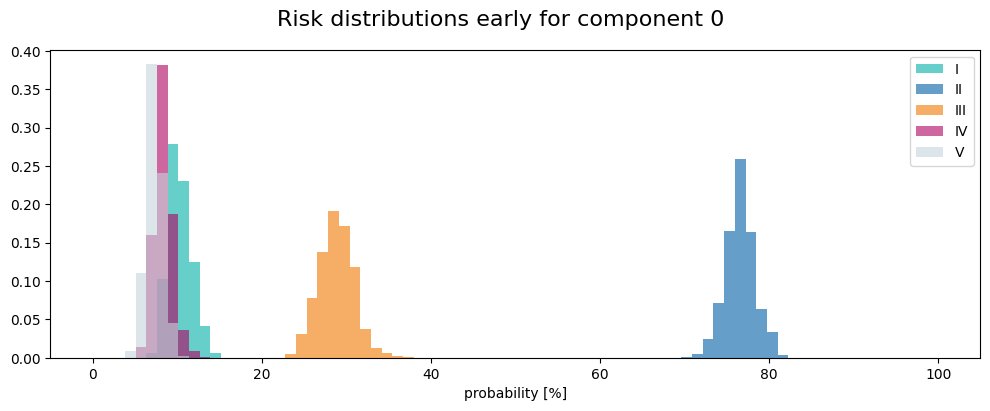

In [209]:
multiple_plotter_component(component_dictionary_early['0'], '0', 'early')

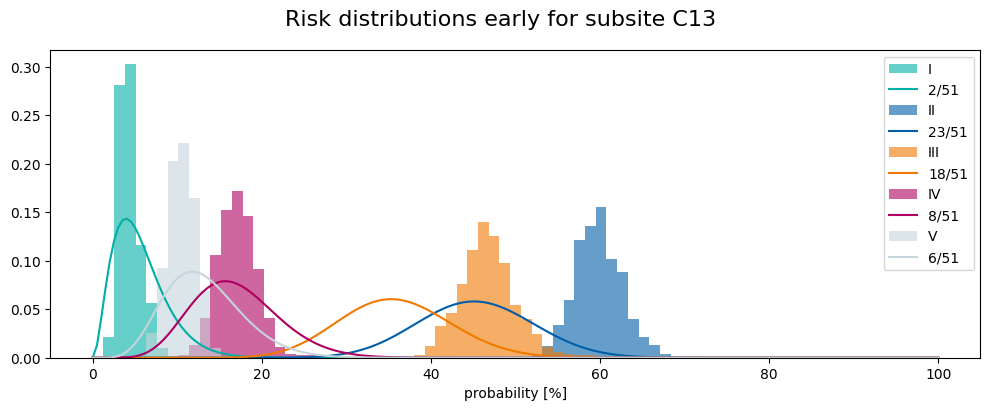

In [189]:
subsite = 'C13'
multiple_plotter(dataset= dataset_staging_main_groups, risk_dictionary = subsite_dictionary[subsite], subsite = subsite, stage = 'early' )

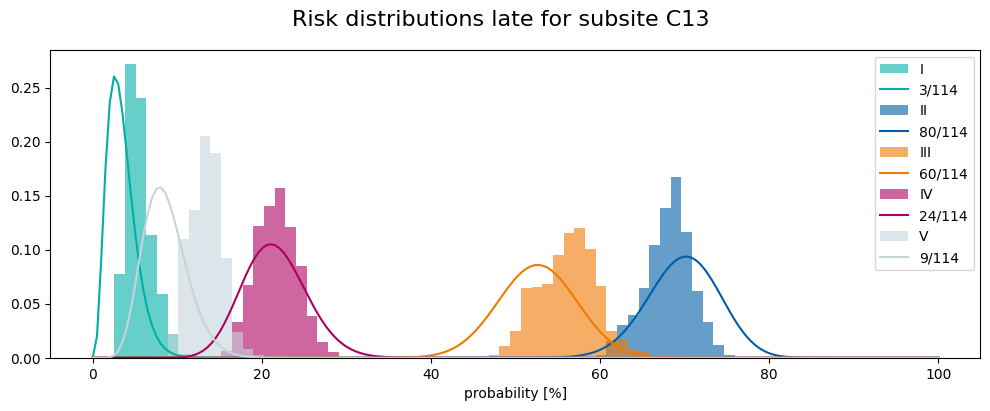

In [190]:
multiple_plotter(dataset= dataset_staging_main_groups, risk_dictionary = subsite_dictionary_late[subsite], subsite = subsite, stage = 'late' )

In [82]:
import matplotlib.gridspec as gs
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from cycler import cycler
import corner
def corner_plotter(samples, mixture, selection):
    usz_blue = '#005ea8'
    usz_green = '#00afa5'
    usz_red = '#ae0060'
    usz_orange = '#f17900'
    usz_gray = '#c5d5db'

    white_to_blue  = LinearSegmentedColormap.from_list("white_to_blue", 
                                                    ["#ffffff", usz_blue], 
                                                    N=256)

    h = usz_gray.lstrip('#')
    gray_rgba = tuple(int(h[i:i+2], 16) / 255. for i in (0, 2, 4)) + (1.0,)
    tmp = LinearSegmentedColormap.from_list("tmp", [usz_green, usz_red], N=128)
    tmp = tmp(np.linspace(0., 1., 128))
    tmp = np.vstack([np.array([gray_rgba]*128), tmp])


    def set_size(width="single", unit="cm", ratio="golden"):
        if width == "single":
            width = 10
        elif width == "full":
            width = 20
        else:
            try:
                width = width
            except:
                width = 10
                
        if unit == "cm":
            width = width / 2.54
            
        if ratio == "golden":
            ratio = 1.618
        else:
            ratio = ratio
        
        try:
            height = width / ratio
        except:
            height = width / 1.618
            
        return (width, height)


    labels = np.array(list(mixture.get_params().keys()))[selection]
    samples_selected = samples[:,selection]
    fig = plt.figure(figsize=set_size(width="full", ratio='golden'))

    corner.corner(samples_selected, labels=labels, smooth=True, fig=fig, 
                hist_kwargs={'histtype': 'stepfilled', 'color': usz_blue}, 
                **{'plot_datapoints': False, 'no_fill_contours': True, 
                    "density_cmap": white_to_blue.reversed(), 
                    "contour_kwargs": {"colors": "k"}, 
                    "levels": np.array([0.2, 0.5, 0.8])}, 
                show_titles=True, title_kwargs={"fontsize": 9},labelpad =0.25)

    axes = fig.get_axes()
    for ax in axes:
        ax.grid(False)
        ax.tick_params(axis='both', labelsize=5)

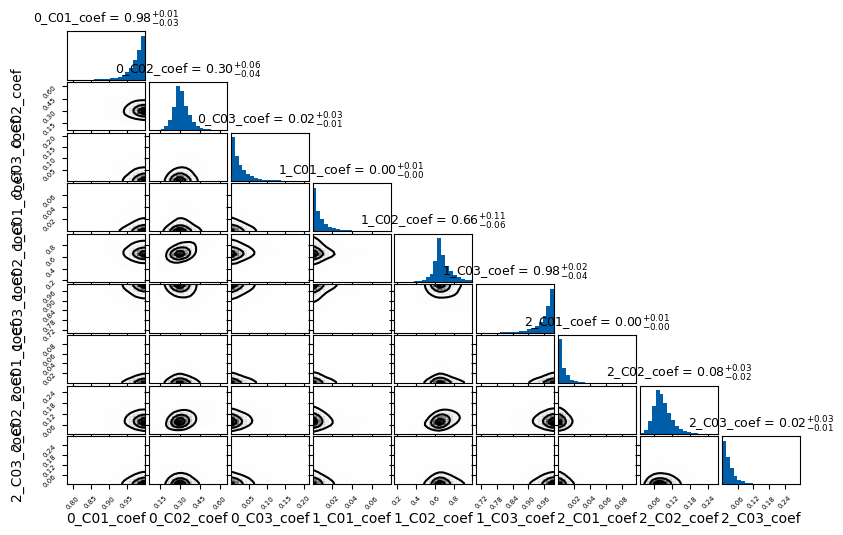

In [90]:
corner_plotter(full_samples,mixture,[10,11,12,30,31,32,50,51,52])

## latent sampling approach

In [10]:
original_latent = mixture.get_resps()

In [11]:
def sample_latent(df):
    sampled_df = pd.DataFrame(0, index=df.index, columns=df.columns)  # Create a DataFrame of zeros
    for index, row in df.iterrows():
        sampled_index = np.random.choice(df.columns, p=row)  # Sample based on the probabilities in the row
        sampled_df.at[index, sampled_index] = 1  # Set the sampled column to 1
    return sampled_df

In [ ]:
params_samples = []


In [39]:
for i in range(num_samples):
    latent = sample_latent(original_latent)

KeyboardInterrupt: 

In [70]:
num_samples = 4000
lister = []
for i in range(num_samples):
    latent = sample_latent(original_latent)
    empty_dataframe.loc[i] = latent.sum()
    lister.append(latent)

In [71]:
lister_evaluated = []
for i in range(len(lister)-1):
    lister_evaluated.append(np.abs((lister[0]-lister[i+1]).sum()).sum()/2)


Text(0.5, 1.0, 'histogram of differences between latent samples')

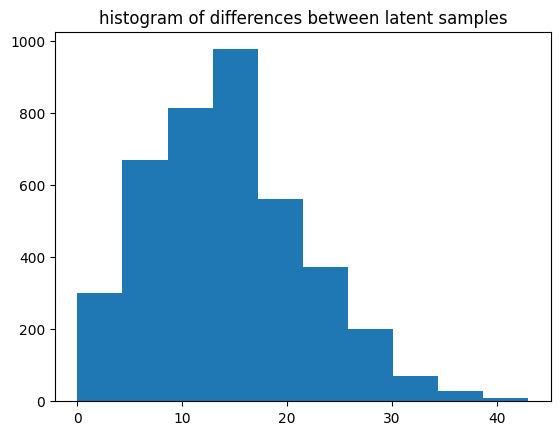

In [72]:
plt.hist(lister_evaluated)
plt.title('histogram of differences between latent samples')

In [31]:
num_samples = 300
for i in range(num_samples):
    latent = sample_latent(original_latent)
    params = maximization(mixture, latent)
    params_samples.append(params)
    print(i, 'th run with likelihood', mixture.likelihood(use_complete=True))

0 th run with likelihood -3650.645339204221
1 th run with likelihood -3624.01982713676
2 th run with likelihood -3608.615980156369
3 th run with likelihood -3618.010323653184
4 th run with likelihood -3600.469461495273
5 th run with likelihood -3578.6991366946604
6 th run with likelihood -3663.4422374288633
7 th run with likelihood -3624.1336815782224
8 th run with likelihood -3646.702676954959
9 th run with likelihood -3607.650855570929
10 th run with likelihood -3619.2548964023863
11 th run with likelihood -3632.0809960776314
12 th run with likelihood -3650.4210210732303
13 th run with likelihood -3638.1526265043904
14 th run with likelihood -3613.5943164944993
15 th run with likelihood -3631.8935380479306
16 th run with likelihood -3577.9919993826047
17 th run with likelihood -3598.3178257502036
18 th run with likelihood -3628.851928525198
19 th run with likelihood -3607.864496992477
20 th run with likelihood -3607.614464999441
21 th run with likelihood -3619.7228992549453
22 th run

KeyboardInterrupt: 

In [32]:
component_dictionary_early = {}

In [34]:
len(params_samples)

377

In [33]:
for component in component_list:
    risk_dictionary = {
        'I': [],
        'II': [],
        'III': [],
        'IV': [],
        'V': []
    }
    for sample in params_samples:
        mixture.set_params(**sample)
        risk_dictionary['I'].append(mixture.components[component].risk(involvement = involvement_I, t_stage = 'early'))
        risk_dictionary['II'].append(mixture.components[component].risk(involvement = involvement_II, t_stage = 'early'))
        risk_dictionary['III'].append(mixture.components[component].risk(involvement = involvement_III, t_stage = 'early'))
        risk_dictionary['IV'].append(mixture.components[component].risk(involvement = involvement_IV, t_stage = 'early'))
        risk_dictionary['V'].append(mixture.components[component].risk(involvement = involvement_V, t_stage = 'early'))

    component_dictionary_early[str(component)] = risk_dictionary

In [35]:
import matplotlib.pyplot as plt

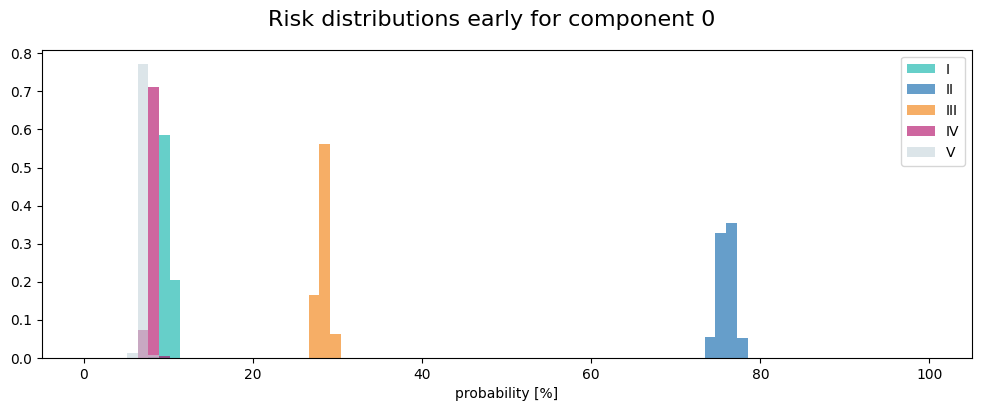

In [36]:
multiple_plotter_component(component_dictionary_early['0'], '0', 'early')

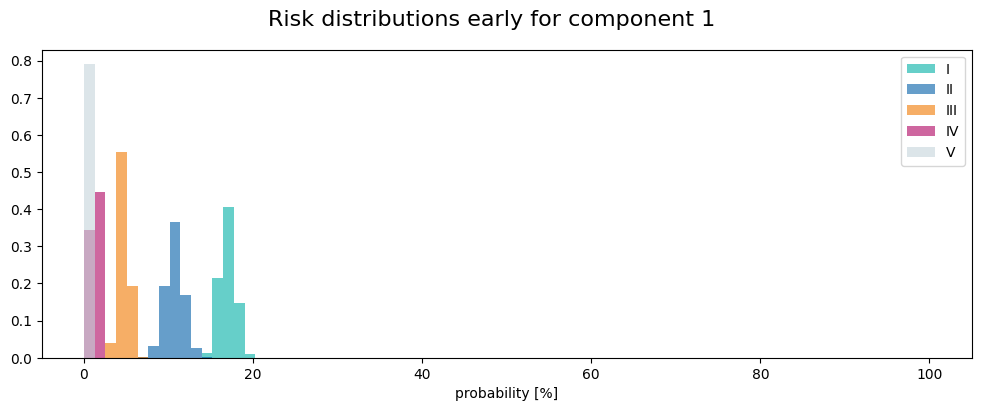

In [37]:
multiple_plotter_component(component_dictionary_early['1'], '1', 'early')

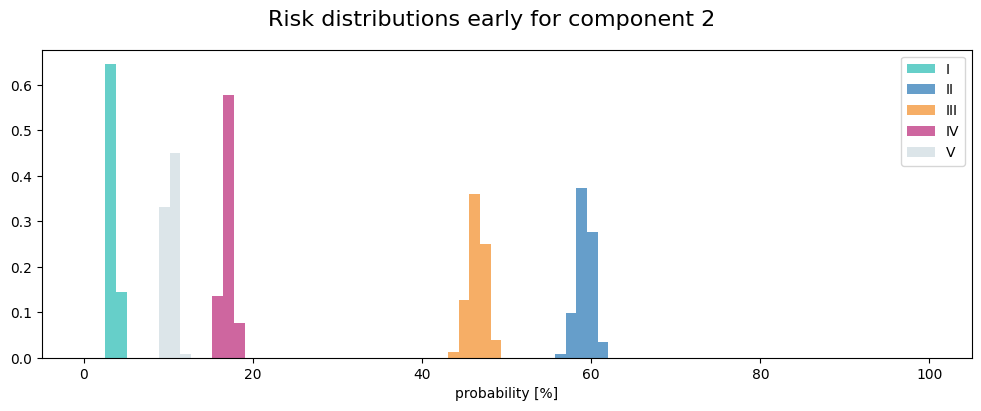

In [38]:
multiple_plotter_component(component_dictionary_early['2'], '2', 'early')

## IP algorithm

step 1: sample from the posterior of the latent variables

In [5]:
original_latent = mixture.get_resps()

In [6]:
original_latent

,0,1,2
0,1.000000e+00,4.159111e-11,1.143899e-10
1,1.000000e+00,2.185778e-11,3.644717e-10
2,1.000000e+00,4.159111e-11,1.143899e-10
3,1.000000e+00,1.086967e-14,4.468557e-10
4,1.000000e+00,2.588928e-11,1.224343e-10
...,...,...,...
1629,9.684658e-07,1.058982e-16,9.999990e-01
1630,1.022169e-06,3.842303e-15,9.999990e-01
1631,3.085741e-06,6.420344e-16,9.999969e-01
1632,5.448504e-07,2.059783e-17,9.999995e-01


In [7]:
def sample_latent(df):
    sampled_df = pd.DataFrame(0, index=df.index, columns=df.columns)  # Create a DataFrame of zeros
    for index, row in df.iterrows():
        sampled_index = np.random.choice(df.columns, p=row)  # Sample based on the probabilities in the row
        sampled_df.at[index, sampled_index] = 1  # Set the sampled column to 1
    return sampled_df

In [8]:
latent = sample_latent(original_latent)


step 2: sample from the posterior of the model parameters

In [9]:
from lymixture.em import sample_model_params

samples = sample_model_params(model = mixture, steps = 10, latent = latent)

100%|██████████| 10/10 [03:07<00:00, 18.75s/it]


In [10]:
mixture.set_params(*samples[-1])

()

In [11]:
mixture.get_params()

{'0_TtoI_spread': 0.03448415197888068,
 '0_TtoII_spread': 0.43443654462543135,
 '0_TtoIII_spread': 0.06979800292422436,
 '0_TtoIV_spread': 0.009904315150891208,
 '0_TtoV_spread': 0.020098876703871168,
 '0_ItoII_spread': 0.6826600488915713,
 '0_IItoIII_spread': 0.10649059841713251,
 '0_IIItoIV_spread': 0.16946810273761256,
 '0_IVtoV_spread': 0.15734077946169775,
 '0_late_p': 0.3907155295293958,
 '0_C01_coef': 0.9999983100371744,
 '0_C02_coef': 0.25316444982317277,
 '0_C03_coef': 2.2196525323272617e-07,
 '0_C04_coef': 0.12121184472061565,
 '0_C05_coef': 0.3770498628952121,
 '0_C06_coef': 1.2151587170255256e-06,
 '0_C09_coef': 0.8893791715341414,
 '0_C10_coef': 0.514792832369538,
 '0_C12_coef': 4.269045173643348e-07,
 '0_C13_coef': 9.080957710441825e-07,
 '1_TtoI_spread': 0.061232236451107744,
 '1_TtoII_spread': 0.02657928926583033,
 '1_TtoIII_spread': 0.013843869952335651,
 '1_TtoIV_spread': 0.0040712367389909975,
 '1_TtoV_spread': 6.766698620862633e-05,
 '1_ItoII_spread': 0.163946297919

In [15]:
llhs = mixture.patient_mixture_likelihoods(None, log= True)
resps = mixture.get_resps(t_stage = None).to_numpy()
np.sum(resps * llhs) if True else np.prod(llhs ** resps)

/home/yoel/Documents/Mixture_model/.venv/lib/python3.10/site-packages/lymixture/models.py:480: RuntimeWarning: invalid value encountered in log
  full_mixture_coefs_log = np.log(full_mixture_coefs)
/tmp/ipykernel_11358/4126994375.py:3: RuntimeWarning: invalid value encountered in multiply
  np.sum(resps * llhs) if True else np.prod(llhs ** resps)


nan

In [15]:
mixture.set_resps(latent)

In [18]:
mixture.get_resps(9)

0    1.0
1    0.0
2    0.0
Name: 9, dtype: float64

In [32]:
mixture.set_params(*params_samples[30])

()

In [33]:
expectation(mixture, mixture.get_params())

array([[9.99999315e-01, 3.83321603e-07, 3.01397915e-07],
       [9.99998838e-01, 2.01614976e-07, 9.60148696e-07],
       [9.99999315e-01, 3.83321603e-07, 3.01397915e-07],
       ...,
       [5.26818137e-07, 2.45923598e-07, 9.99999227e-01],
       [9.30620240e-08, 1.15699279e-08, 9.99999895e-01],
       [5.26818137e-07, 2.45923598e-07, 9.99999227e-01]])

### Full round of IP

In [41]:
pd.DataFrame(latent_exp)

,0,1,2
0,9.999995e-01,2.590353e-07,2.401372e-07
1,9.999991e-01,1.362443e-07,7.649835e-07
2,9.999995e-01,2.590353e-07,2.401372e-07
3,9.999991e-01,9.826369e-11,9.376025e-07
4,9.999996e-01,1.612985e-07,2.570215e-07
...,...,...,...
1629,6.700076e-07,5.740028e-08,9.999993e-01
1630,7.070852e-07,2.079459e-06,9.999972e-01
1631,2.134380e-06,3.476533e-07,9.999975e-01
1632,3.770499e-07,1.646002e-08,9.999996e-01


In [40]:
latent_exp=expectation(mixture, mixture.get_params())

In [172]:
import emcee
from multiprocessing import Pool

def log_prob_fn2(theta, model):
    lower_bounds = np.zeros(len(theta))
    upper_bounds = np.ones(len(theta)) 

    # Check if the parameters are within bounds
    if np.any(theta < lower_bounds) or np.any(theta > upper_bounds):
        return -np.inf  # Return -infinity if out of bounds
    model.set_params(*theta)
    return model.likelihood(log=True, use_complete = True)

def sample_model_params_continue_chain(model, steps = 100, chain = None, latent = None):
    if latent is None:
        latent = model.get_resps()
    model.set_resps(latent)
    model.set_mixture_coefs(model.compute_mixture())
    current_params = list(model.get_params(as_dict = False))
    ndim = len(current_params)
    nwalkers = 5 * ndim
    if chain is None:
        ndim = len(current_params)
        nwalkers = 5 * ndim
        perturbation = 1e-4 * abs(np.random.randn(nwalkers, ndim))
        starting_points = np.ones((nwalkers, ndim)) * current_params + perturbation
        starting_points[starting_points > 1] = 1 - perturbation[starting_points > 1]
    else:
        starting_points = chain
    with Pool() as pool:
        original_sampler = emcee.EnsembleSampler(
            nwalkers, ndim, log_prob_fn2,
            args=(model,),
            pool=pool,
        )
        original_sampler.run_mcmc(initial_state=starting_points, nsteps=steps, progress=True)
    ar = np.mean(original_sampler.acceptance_fraction)
    print(f"Mean acceptance rate: {ar * 100 :.2f}%")
    return original_sampler.get_chain(discard=0, thin=1, flat=False)

In [154]:
samples = sample_model_params_continue_chain(model = mixture, steps = 5, latent = latent)

100%|██████████| 5/5 [01:33<00:00, 18.67s/it]

Mean acceptance rate: 9.27%


In [128]:
len(mixture.get_params())

60

In [132]:
samples.reshape()

(300, 60)

In [160]:
new_latent = expectation(mixture, mixture.get_params())

In [165]:
latent_or = sample_latent(original_latent)
(latent_or -original_latent).sum()

0    2.389597
1    1.693971
2   -4.083568
dtype: float64

In [162]:
(new_latent - original_latent).sum()

0    3.113637
1   -1.809695
2   -1.303942
dtype: float64

In [170]:
abs((latent - latent_or).sum()).sum()/2

34.0

In [163]:
latent = sample_latent(pd.DataFrame(latent_exp))

In [279]:
all_samples_starting_from_101 = []

In [280]:
IP_rounds = 170
n_steps = 100
n_dim = len(mixture.get_params())
n_walkers = 5 * n_dim
# params_samples = []
# latent_samples = []
# complete_likelihoods = []
# incomplete_likelihoods = []
# latent = sample_latent(original_latent)
# chain = None
for round in range(IP_rounds):
    samples = sample_model_params_continue_chain(model = mixture, steps = n_steps, chain = chain, latent = latent)
    chain = samples[-1]
    samples_flat = samples.reshape(n_steps * n_walkers, n_dim)
    latent_samples.append(latent)
    params_samples.append(samples_flat[-1])
    mixture.set_params(*samples_flat[-1])
    latent_exp = expectation(mixture, mixture.get_params())
    all_samples_starting_from_101.append(samples_flat)
    complete_likelihoods.append(mixture.likelihood(use_complete=True))
    incomplete_likelihoods.append(mixture.likelihood(use_complete=False))
    latent = sample_latent(pd.DataFrame(latent_exp))
    print('latent difference = ',abs((latent - latent_samples[-1]).sum()).sum()/2)
    print(round, 'th run with complete likelihood', complete_likelihoods[-1], ' and incomplete likelihood', incomplete_likelihoods[-1])

100%|██████████| 100/100 [28:19<00:00, 16.99s/it]


Mean acceptance rate: 8.27%
latent difference =  32.0
0 th run with complete likelihood -3981.0860858190645  and incomplete likelihood -3258.3571890423063


100%|██████████| 100/100 [28:04<00:00, 16.84s/it]


Mean acceptance rate: 7.82%
latent difference =  46.0
1 th run with complete likelihood -3980.7341601640874  and incomplete likelihood -3255.9475582916625


100%|██████████| 100/100 [28:03<00:00, 16.83s/it]


...

Mean acceptance rate: 5.86%
latent difference =  34.0
167 th run with complete likelihood -3995.1096501128327  and incomplete likelihood -3241.3549628627934


100%|██████████| 100/100 [27:05<00:00, 16.25s/it]


Mean acceptance rate: 5.68%
latent difference =  21.0
168 th run with complete likelihood -3933.102595121178  and incomplete likelihood -3242.069849596909


100%|██████████| 100/100 [27:15<00:00, 16.35s/it]


Mean acceptance rate: 5.75%
latent difference =  43.0
169 th run with complete likelihood -3965.8551938998944  and incomplete likelihood -3241.3576459239976


In [268]:
latent = latent_samples[-1]

(array([ 1., 45., 79., 15., 26., 76., 18.,  7.,  2.,  2.]),
 array([0.01111282, 0.0130747 , 0.01503658, 0.01699846, 0.01896034,
        0.02092222, 0.0228841 , 0.02484598, 0.02680785, 0.02876973,
        0.03073161]),
 <BarContainer object of 10 artists>)

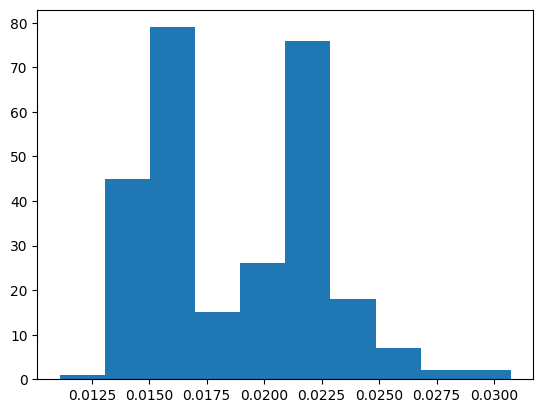

In [281]:
plt.hist(np.array(params_samples)[:,4])

(array([ 7.,  4.,  9., 24., 21., 36., 40., 56., 12., 62.]),
 array([-3270.44701837, -3266.46930235, -3262.49158634, -3258.51387033,
        -3254.53615431, -3250.5584383 , -3246.58072228, -3242.60300627,
        -3238.62529025, -3234.64757424, -3230.66985822]),
 <BarContainer object of 10 artists>)

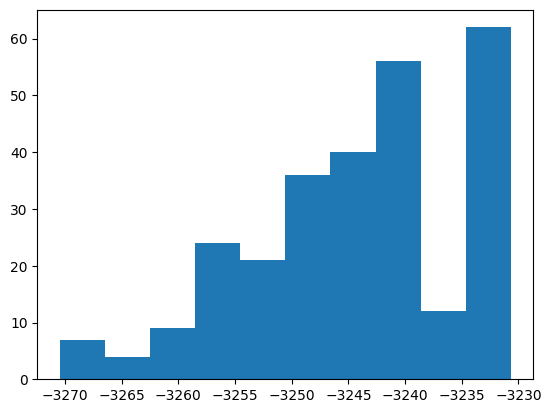

In [283]:
plt.hist(incomplete_likelihoods)

In [188]:
mixture.set_params(*params_samples[-4])

()

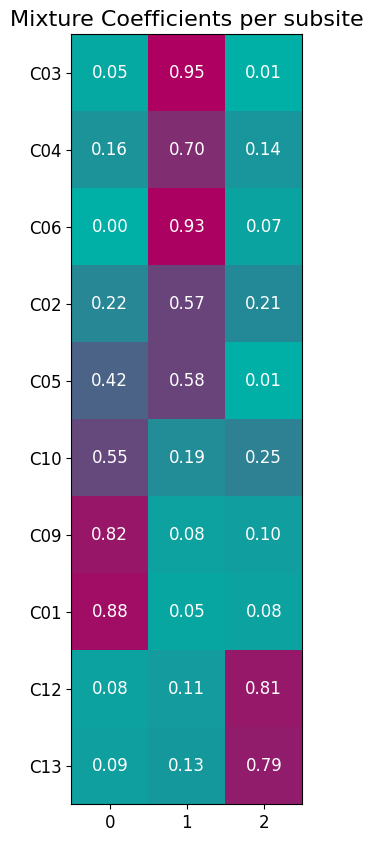

In [284]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# USZ colors
usz_blue = '#005ea8'
usz_green = '#00afa5'
usz_red = '#ae0060'
usz_orange = '#f17900'
usz_gray = '#c5d5db'

# colormaps
white_to_blue  = LinearSegmentedColormap.from_list("white_to_blue", 
                                                   ["#ffffff", usz_blue], 
                                                   N=256)
white_to_green = LinearSegmentedColormap.from_list("white_to_green", 
                                                   ["#ffffff", usz_green], 
                                                   N=256)
green_to_red   = LinearSegmentedColormap.from_list("green_to_red", 
                                                   [usz_green, usz_red], 
                                                   N=256)

h = usz_gray.lstrip('#')
gray_rgba = tuple(int(h[i:i+2], 16) / 255. for i in (0, 2, 4)) + (1.0,)
tmp = LinearSegmentedColormap.from_list("tmp", [usz_green, usz_red], N=128)

matrix = mixture.get_mixture_coefs()[['C03', 'C04', 'C06', 'C02', 'C05', 'C10', 'C09', 'C01', 'C12', 'C13']]

# Transpose the matrix to rotate by 90°
matrix_rotated = matrix.T

# Create the figure and axis
fig, ax = plt.subplots(figsize=(8, 10))

# Display the rotated matrix using imshow
cax = ax.imshow(matrix_rotated.values, cmap=tmp, origin='upper')

# Loop over the data and create text annotations
for i in range(matrix_rotated.shape[0]):  # Rows (previously columns)
    for j in range(matrix_rotated.shape[1]):  # Columns (previously rows)
        value = matrix_rotated.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", 
                color="white", fontsize=12)


# Optional: Set axis labels and title
ax.set_xticks(range(matrix_rotated.shape[1]))
ax.set_xticklabels(matrix.index, fontsize = 12)  # Original row labels
ax.set_yticks(range(matrix_rotated.shape[0]))
ax.set_yticklabels(matrix.columns, fontsize = 12)  # Original column labels
ax.set_title("Mixture Coefficients per subsite", fontsize = 16)
plt.show()


In [285]:
asdf = (latent_samples[3]-latent_samples[4])
asdf.value_counts()[1:].sum()

217

In [286]:
latenter_diff = []
for i in range(1, len(latent_samples)):
    latenter_diff.append(abs((latent_samples[i-1]-latent_samples[i])).sum().sum()/2)

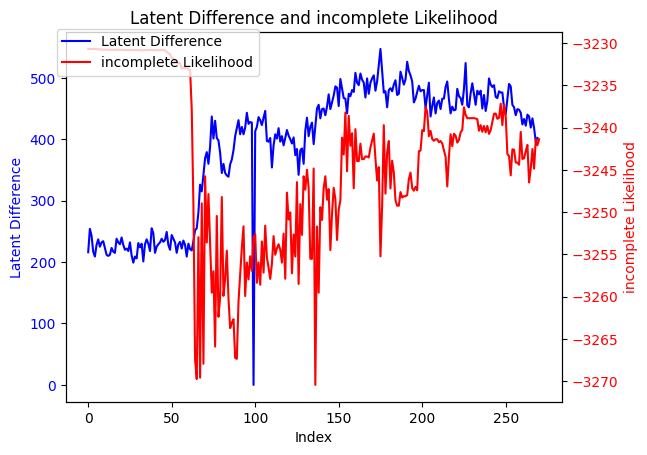

In [305]:
fig, ax1 = plt.subplots()

# Plot the first dataset (latenter_diff) on the primary y-axis
ax1.plot(latenter_diff, label='Latent Difference', color='blue')
ax1.set_xlabel('Index')
ax1.set_ylabel('Latent Difference', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create the secondary y-axis
ax2 = ax1.twinx()

# Plot the second dataset (incomplete_likelihoods) on the secondary y-axis
ax2.plot(incomplete_likelihoods, label='incomplete Likelihood', color='red')
ax2.set_ylabel('incomplete Likelihood', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Show the legend
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

# Display the plot
plt.title("Latent Difference and incomplete Likelihood")
plt.show()

(array([  1.,   0.,   0.,  18.,  48.,   3.,  18.,  58., 102.,  22.]),
 array([  0. ,  54.7, 109.4, 164.1, 218.8, 273.5, 328.2, 382.9, 437.6,
        492.3, 547. ]),
 <BarContainer object of 10 artists>)

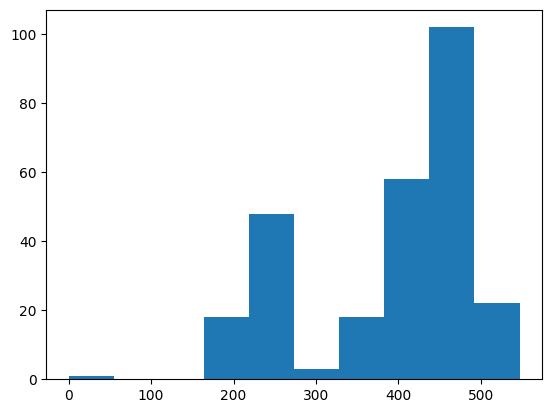

In [300]:
plt.hist(latenter_diff)

In [255]:
abs((latent_samples[3]-latent_samples[4])).sum().sum()/2

217.0

In [289]:
sampled_latent_from_original.loc[np.any(abs((sampled_latent_from_original - np.round(original_latent,1))) > 0.2, axis = 1)]

,0,1,2
218,0,0,1
220,1,0,0
224,1,0,0
225,0,1,0
226,1,0,0
...,...,...,...
1233,0,0,1
1235,0,0,1
1238,0,0,1
1240,0,1,0


(array([73., 12., 17., 75., 55.,  7.,  7., 16.,  8.,  1.]),
 array([0.42514883, 0.44529251, 0.46543618, 0.48557986, 0.50572354,
        0.52586722, 0.5460109 , 0.56615458, 0.58629826, 0.60644194,
        0.62658562]),
 <BarContainer object of 10 artists>)

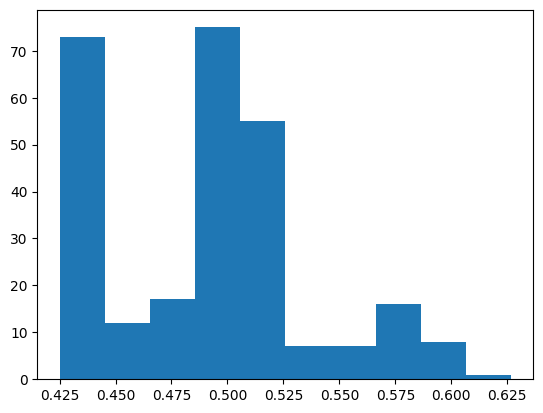

In [301]:
plt.hist(np.array(params_samples)[:,1])

In [302]:
differences = [params_samples[i+1] - params_samples[i] for i in range(len(params_samples) - 1)]
sums_of_differences = [differences[k].sum() for k in range(len(differences))]
sums_of_differences

[4.359673522690428e-05,
 8.01230940525246e-06,
 0.0,
 -3.0392155724546278e-06,
 0.00011821061559647795,
 0.00011247822857080904,
 -3.539419887777793e-05,
 0.0001150552383239586,
 -8.613009940674393e-06,
 0.0,
 8.762731563295702e-05,
 0.0,
 0.0,
 -1.0925468464116187e-05,
 2.016838508785165e-05,
 -4.3655879701774955e-05,
 4.822810376382073e-05,
 3.888175668792197e-06,
 5.062434711095859e-06,
 0.0003753678010373584,
 -7.580368480105774e-06,
 9.161600748954829e-05,
 -6.244950568845618e-06,
 0.0,
 8.489121337972315e-06,
 -0.00017559676874840074,
 5.9612609466118914e-05,
 -4.906656011356661e-05,
 2.9739958194247194e-05,
 -4.852132043330589e-05,
 2.1462385349054206e-05,
 0.00012006897294405939,
 4.960273695743403e-06,
 -1.3148250753021381e-05,
 -1.7446399972231584e-06,
 0.0,
 -5.125161078259637e-05,
 -1.7160422978596747e-06,
 0.00016408034099442344,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 -4.330972315207675e-06,
 0.003197686003349601,
 0.0008029311318064562,
 0.00072733847742407,
 0.003365098809

In [303]:
involvement_I = {'I': True}
involvement_II = {'II': True}
involvement_III = {'III': True}
involvement_IV = {'IV': True}
involvement_V = {'V': True}
component_list = list(range(len(mixture.components)))
component_dictionary_early = {}


In [293]:
for component in component_list:
    risk_dictionary = {
        'I': [],
        'II': [],
        'III': [],
        'IV': [],
        'V': []
    }
    for sample in params_samples:
        mixture.set_params(*sample)
        risk_dictionary['I'].append(mixture.components[component].risk(involvement = involvement_I, t_stage = 'early'))
        risk_dictionary['II'].append(mixture.components[component].risk(involvement = involvement_II, t_stage = 'early'))
        risk_dictionary['III'].append(mixture.components[component].risk(involvement = involvement_III, t_stage = 'early'))
        risk_dictionary['IV'].append(mixture.components[component].risk(involvement = involvement_IV, t_stage = 'early'))
        risk_dictionary['V'].append(mixture.components[component].risk(involvement = involvement_V, t_stage = 'early'))

    component_dictionary_early[str(component)] = risk_dictionary

In [294]:
component_dictionary_early['0']

{'I': [0.12263621907474333,
  0.12265119043264334,
  0.1226629714905999,
  0.1226629714905999,
  0.12266313144100409,
  0.12269721412498275,
  0.12273777146909651,
  0.12272103937909454,
  0.12278177892122201,
  0.12277848011257123,
  0.12277848011257123,
  0.12282772374176423,
  0.12282772374176423,
  0.12282772374176423,
  0.12282099185132729,
  0.12282980170781141,
  0.12282047136897825,
  0.122841572335132,
  0.12284774197804767,
  0.1228564773476543,
  0.12296498361773964,
  0.12296255379458379,
  0.12299315837470262,
  0.12299167788729626,
  0.12299167788729626,
  0.12299602371135035,
  0.12289729449031059,
  0.12291664454410473,
  0.12289716501295042,
  0.12291458454052001,
  0.12289518622013625,
  0.12289709216265182,
  0.12293428993381014,
  0.12293673741518972,
  0.12296136409261799,
  0.12296260004883358,
  0.12296260004883358,
  0.12294418582401011,
  0.12294443980728023,
  0.1229789381062407,
  0.1229789381062407,
  0.1229789381062407,
  0.1229789381062407,
  0.12297893810

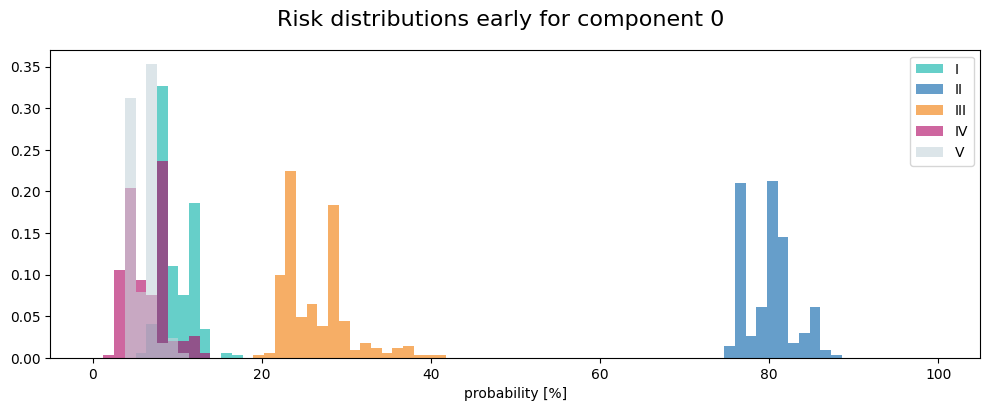

In [295]:
multiple_plotter_component(component_dictionary_early['0'], '0', 'early')

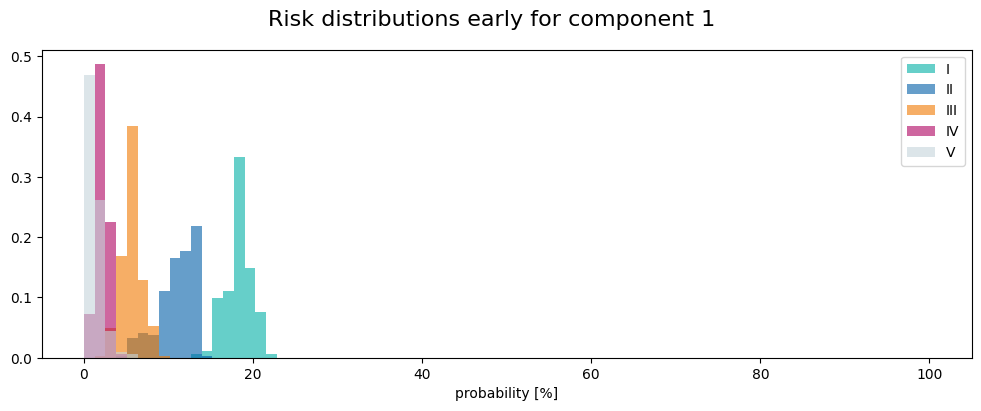

In [296]:
multiple_plotter_component(component_dictionary_early['1'], '1', 'early')

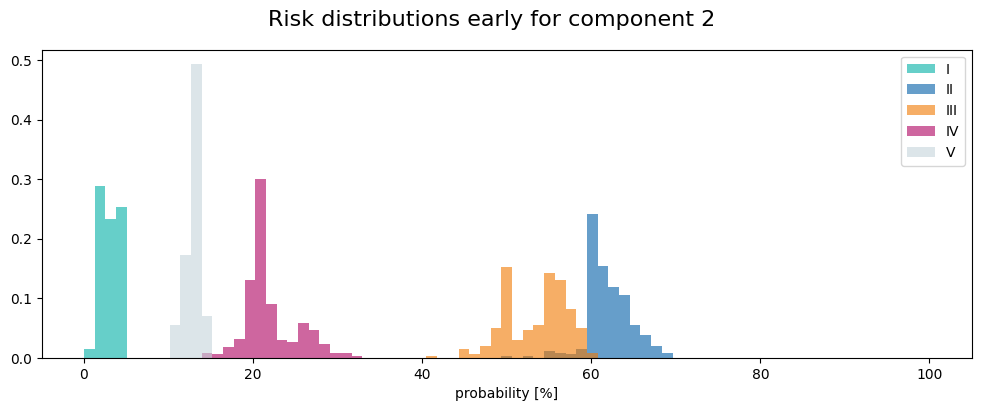

In [297]:
multiple_plotter_component(component_dictionary_early['2'], '2', 'early')